In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import torch
import numpy as np
sys.path.append(os.path.abspath('../scripts'))
from supporting.load_data import load_data, build_data_loaders, x_scale, y_scale, y_unscale
from sklearn import metrics
from torch import nn, optim
import torch.nn.functional as F


In [2]:
def get_device():
    ''' function to get the device the NN is running on, CPU or GPU
    '''
    if torch.cuda.is_available():
        device = torch.device("cuda:0")
    else: 
        device = torch.device("cpu")
        
    return device


In [3]:
import mlflow
from mlflow.tracking import MlflowClient


In [4]:
import os
os.environ["DATABRICKS_CONFIG_FILE"] = "../secrets/.databrickscfg"

mlflow.login(interactive=False)
print("MLflow login successful.")


2026/04/01 14:07:09 INFO mlflow.utils.credentials: Successfully connected to MLflow hosted tracking server! Host: https://dbc-d0177b72-9a40.cloud.databricks.com.


MLflow login successful.


In [5]:
import mlflow
import json
from mlflow.tracking import MlflowClient

def load_model_artifacts(model_uuid, dst_path):

    client = MlflowClient()

    exp = client.get_experiment_by_name(
        "/Users/harish.akula096@gmail.com/regressors"
    )
    experiment_id = exp.experiment_id

    runs = mlflow.search_runs(
        experiment_ids=[experiment_id],
        filter_string=f"tags.mlflow.runName = '{model_uuid}'"
    )

    run_id = runs.iloc[0]["run_id"]

    weights_path = client.download_artifacts(
        run_id,
        f"{model_uuid}.best_weights.pt",
        dst_path=dst_path
    )

    config_path = client.download_artifacts(
        run_id,
        "config.json",
        dst_path=dst_path
    )

    with open(config_path) as f:
        config = json.load(f)

    return weights_path, config

# weights_path, config = load_model_artifacts("y27y28m1", "./artifacts")


In [6]:
# config["data_dir"] = "/scratch/akula.ha/dataset"


In [7]:
torch.set_default_dtype(torch.float64)


In [9]:
class MyDataset(torch.utils.data.Dataset):
    '''Class to convert dataframe to torch tensor'''
    def __init__(self, x, y, config):
        x = x.copy(deep=True)
        y = y.copy(deep=True)

        # Vectorized scaling (if applicable)
        x['x1'] = x_scale(x['x1'])  # Or use apply if x_scale isn't vectorized

        # Number of targets
        config['n_targets'] = y.shape[1]

        for column in y.columns:
            y[column] = y[column].apply(y_scale)

        device = get_device()
        self.x = torch.tensor(x.values, dtype=torch.float64).to(device)
        self.y = torch.tensor(y.values, dtype=torch.float64).reshape(-1, config['n_targets']).to(device)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# df, spark = load_data(config)

# x_cols = ['x1', 'x2', 'x3', 'x4']
# y_cols = config["var_y"]
# x_train = df["train"][x_cols]
# y_train = df["train"][y_cols]
# x_val = df["validate"][x_cols]
# y_val = df["validate"][y_cols]
# x_test = df["test"][x_cols]
# y_test = df["test"][y_cols]

# train_dataset = MyDataset(x_train, y_train, config)
# val_dataset   = MyDataset(x_val, y_val, config)
# test_dataset  = MyDataset(x_test, y_test, config)

# load the data into torch tensor batches
# batch_size = config["batch_size"]
# numworkers = 4 if get_device().type == 'cpu' else 0

# train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
# val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
# test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=numworkers, drop_last=True)



In [10]:
# model_path = weights_path # "/home/hakula/qqzz4l-NN/models/skip-mini_ff414e9e_30_12_5/ff414e9e.best_weights.pt"

In [11]:
from sklearn.metrics import r2_score

def safe_mape(y_true, y_pred, eps=1e-6):
    """
    Mean Absolute Percentage Error with denominator guard.
    Adds eps to denominator to avoid blow-up near zero.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps)))


def _percent_delta(y_true, y_pred, eps=1e-6):
    """
    Percentage delta with epsilon guard:
    (y_pred - y_true) / (y_true + eps) * 100
    """
    return (y_pred - y_true) / (y_true + eps) * 100.0


def _plot_error_histograms(delta_matrix, labels, cutoff=5, title="Error Histogram Overlay"):
    """Overlay histogram for each target column in delta_matrix."""
    plt.figure(figsize=(8, 5))
    for j, name in enumerate(labels):
        col = delta_matrix[:, j]
        m = np.isfinite(col)
        if cutoff is not None:
            m &= (np.abs(col) < cutoff)
        data = col[m]
        if data.size == 0:
            continue
        plt.hist(data, bins=100, histtype='step', label=name, density=True)
    plt.grid(True, linestyle='dotted', alpha=0.5)
    plt.xlabel(r'$\delta$ (%)')
    plt.ylabel('pdf')
    plt.title(title)
    plt.legend()
    plt.show()


def evaluate_model(model, dataloader, device, config, eps=1e-6):
    """
    Evaluate a trained model and display metrics and histograms.
    eps: small constant to stabilize denominators in MAPE and deltas.
    """
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            pred = model(xb).cpu()
            all_preds.append(pred)
            all_targets.append(yb.cpu())

    y_true = torch.cat(all_targets, dim=0).numpy()
    y_pred = torch.cat(all_preds, dim=0).numpy()

    y_names = config["var_y"]
    assert y_true.ndim == 2 and y_true.shape[1] == len(y_names)

    # --- Scaled metrics ---
    scaled = {}
    overall_mape = safe_mape(y_true, y_pred, eps=eps)
    overall_r2   = r2_score(y_true, y_pred)
    overall_abs  = (1 - overall_mape) * 100 if np.isfinite(overall_mape) else np.nan
    scaled["overall"] = {"MAPE": overall_mape, "R2": overall_r2, "abs_score": overall_abs}
    scaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j = safe_mape(y_true[:, j], y_pred[:, j], eps=eps)
        r2_j   = r2_score(y_true[:, j], y_pred[:, j])
        abs_j  = (1 - mape_j) * 100 if np.isfinite(mape_j) else np.nan
        scaled["per_target"][name] = {"MAPE": mape_j, "R2": r2_j, "abs_score": abs_j}

    # --- Unscaled metrics ---
    y_unscale_vec = np.vectorize(y_unscale)
    y_true_un = y_unscale_vec(y_true)
    y_pred_un = y_unscale_vec(y_pred)

    unscaled = {}
    overall_mape_un = safe_mape(y_true_un, y_pred_un, eps=eps)
    overall_r2_un   = r2_score(y_true_un, y_pred_un)
    overall_abs_un  = (1 - overall_mape_un) * 100 if np.isfinite(overall_mape_un) else np.nan
    unscaled["overall"] = {"MAPE": overall_mape_un, "R2": overall_r2_un, "abs_score": overall_abs_un}
    unscaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j_un = safe_mape(y_true_un[:, j], y_pred_un[:, j], eps=eps)
        r2_j_un   = r2_score(y_true_un[:, j], y_pred_un[:, j])
        abs_j_un  = (1 - mape_j_un) * 100 if np.isfinite(mape_j_un) else np.nan
        unscaled["per_target"][name] = {"MAPE": mape_j_un, "R2": r2_j_un, "abs_score": abs_j_un}

    # --- Print results ---
    print("\n=== Evaluation (SCALED) ===")
    print(f"Overall MAPE: {scaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {scaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {scaled['overall']['abs_score']:.6f}")
    for n, v in scaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    print("\n=== Evaluation (UNSCALED) ===")
    print(f"Overall MAPE: {unscaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {unscaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {unscaled['overall']['abs_score']:.6f}")
    for n, v in unscaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    # --- Histograms ---
    scaled_delta   = _percent_delta(y_true, y_pred, eps=eps)
    unscaled_delta = _percent_delta(y_true_un, y_pred_un, eps=eps)

    _plot_error_histograms(unscaled_delta, y_names, cutoff=5, title="Unscaled Errors")
    _plot_error_histograms(scaled_delta, y_names, cutoff=5, title="Scaled Errors")

    return scaled, unscaled


def ensemble_from_checkpoints(model, checkpoint_paths, dataloader, device, config, eps=1e-6):
    """
    Evaluate an ensemble by averaging predictions from multiple checkpoints.
    """
    assert len(checkpoint_paths) > 0, "No checkpoints provided for ensemble"

    all_preds, all_targets = [], []
    model.eval()

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)

            preds_per_ckpt = []
            for path in checkpoint_paths:
                state = torch.load(path, map_location=device)
                model.load_state_dict(state)
                preds_per_ckpt.append(model(xb).cpu())

            mean_pred = torch.stack(preds_per_ckpt, dim=0).mean(dim=0)
            all_preds.append(mean_pred)
            all_targets.append(yb.cpu())

    y_true = torch.cat(all_targets, dim=0).numpy()
    y_pred = torch.cat(all_preds, dim=0).numpy()
    y_names = config["var_y"]

    scaled = {}
    overall_mape = safe_mape(y_true, y_pred, eps=eps)
    overall_r2 = r2_score(y_true, y_pred)
    overall_abs = (1 - overall_mape) * 100 if np.isfinite(overall_mape) else np.nan
    scaled["overall"] = {"MAPE": overall_mape, "R2": overall_r2, "abs_score": overall_abs}
    scaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j = safe_mape(y_true[:, j], y_pred[:, j], eps=eps)
        r2_j = r2_score(y_true[:, j], y_pred[:, j])
        abs_j = (1 - mape_j) * 100 if np.isfinite(mape_j) else np.nan
        scaled["per_target"][name] = {"MAPE": mape_j, "R2": r2_j, "abs_score": abs_j}

    y_unscale_vec = np.vectorize(y_unscale)
    y_true_un = y_unscale_vec(y_true)
    y_pred_un = y_unscale_vec(y_pred)

    unscaled = {}
    overall_mape_un = safe_mape(y_true_un, y_pred_un, eps=eps)
    overall_r2_un = r2_score(y_true_un, y_pred_un)
    overall_abs_un = (1 - overall_mape_un) * 100 if np.isfinite(overall_mape_un) else np.nan
    unscaled["overall"] = {"MAPE": overall_mape_un, "R2": overall_r2_un, "abs_score": overall_abs_un}
    unscaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j_un = safe_mape(y_true_un[:, j], y_pred_un[:, j], eps=eps)
        r2_j_un = r2_score(y_true_un[:, j], y_pred_un[:, j])
        abs_j_un = (1 - mape_j_un) * 100 if np.isfinite(mape_j_un) else np.nan
        unscaled["per_target"][name] = {"MAPE": mape_j_un, "R2": r2_j_un, "abs_score": abs_j_un}

    print("\n=== Ensemble Evaluation (SCALED) ===")
    print(f"Overall MAPE: {scaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {scaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {scaled['overall']['abs_score']:.6f}")
    for n, v in scaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    print("\n=== Ensemble Evaluation (UNSCALED) ===")
    print(f"Overall MAPE: {unscaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {unscaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {unscaled['overall']['abs_score']:.6f}")
    for n, v in unscaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    scaled_delta = _percent_delta(y_true, y_pred, eps=eps)
    unscaled_delta = _percent_delta(y_true_un, y_pred_un, eps=eps)
    _plot_error_histograms(unscaled_delta, y_names, cutoff=5, title="Unscaled Ensemble Errors")
    _plot_error_histograms(scaled_delta, y_names, cutoff=5, title="Scaled Ensemble Errors")

    return scaled, unscaled


def run_ensemble_evaluation(test_df, checkpoint_paths, config, dataloader, eps=0):
    """
    Build a model from config, evaluate an ensemble of checkpoints, and return results.
    """
    print(f"\n{'#' * 80}")
    print(f"Starting ensemble evaluation for targets: {config['var_y']}")
    print(f"Using {len(checkpoint_paths)} checkpoints")
    print(f"{'#' * 80}")

    width = config['width']
    depth = config['depth']
    n_skip_layers = config['skip_block_layers']
    activation = config['activation']

    ensemble_model = SkipModel(
        config["input_shape"],
        width,
        depth,
        n_skip_layers,
        len(config["var_y"]),
        activation,
    )
    ensemble_model.to(device=get_device())

    scaled_metrics, unscaled_metrics = ensemble_from_checkpoints(
        model=ensemble_model,
        checkpoint_paths=checkpoint_paths,
        dataloader=dataloader,
        device=get_device(),
        config=config,
        eps=eps,
    )

    return {
        "checkpoint_paths": checkpoint_paths,
        "config": config,
        "filtered_test_df": test_df.copy(deep=True),
        "scaled_metrics": scaled_metrics,
        "unscaled_metrics": unscaled_metrics,
    }


In [12]:
def test_model(model, test_data, config):
    ''' function for testing the model
        arguments:
            model: the pytorch model to nbe trained
            test_data: the test data loader
            config: the configurations file
        returns:
            the absolute error
            the R2 score
    '''
    
    for i, data in enumerate(test_data):
        
        # forward prop
        x, y = data
        y_p = model(x)
        
        # store data
        if i == 0:
            x_test = x.cpu().detach().numpy()
            y_test = y.cpu().detach().numpy()
            y_pred = y_p.cpu().detach().numpy()
        else: 
            x_test = np.vstack((x_test, x.cpu().detach().numpy()))
            y_test = np.vstack((y_test, y.cpu().detach().numpy()))
            y_pred = np.vstack((y_pred, y_p.cpu().detach().numpy()))
        
    
    # accuracy
    y_test = np.array(y_test).reshape(-1, config['n_targets'])
    y_pred = np.array(y_pred).reshape(-1, config['n_targets'])
    abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100
    r2_score = metrics.r2_score(y_test, y_pred)*100
    
    # save test results
    df_pred = pd.DataFrame(x_test, columns=['x'+str(i+1) for i in range(config['input_shape'])])
    
    # unscale the target
    scaled_cname = [s + '_scaled' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_test, columns=scaled_cname)], axis=1)
    for col in df_pred.columns[4:]:
        df_pred[col[:-7]] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_test_real = pd.DataFrame(np.vectorize(y_unscale)(y_test), columns=config['var_y']) # 
    # df_pred = pd.concat([df_pred, y_test_real], axis=1)
    y_test_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # stuff in the scaled predictions
    pred_cname = [s + '_scaled_pred' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_pred, columns=pred_cname)], axis=1)
    
    # stuff in the unscaled predictions
    pred_cname = [s + '_pred' for s in config['var_y']]
    for col in df_pred.columns[-config['n_targets']:]:
        df_pred[col[:-12]+'_pred'] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_pred_real = pd.DataFrame(np.vectorize(y_unscale)(y_pred), columns=pred_cname) # .apply(lambda y: y_unscale(y))
    # df_pred = pd.concat([df_pred, y_pred_real], axis=1)
    y_pred_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # calculate the deltas for the scaled and unscaled targets
    scaled_delta_cname = ['scaled_delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred - y_test)/y_test*100, columns=scaled_delta_cname)], axis=1)
    delta_cname = ['delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred_real - y_test_real)/y_test_real*100, columns=delta_cname)], axis=1)
    
    #same the whole dataframe

    test_metrics = {}
    test_metrics['r2'] = {}
    test_metrics['abs_score'] = {}
    num_vars = len(config['var_y'])
    base_length = config['input_shape'] + num_vars
    for i in range(base_length, base_length + num_vars):
        test = df_pred.iloc[:,i].values
        pred = df_pred.iloc[:,i + 2 * num_vars].values
        test_metrics['r2'][config['var_y'][i - base_length]] = metrics.r2_score(test, pred)*100
        test_metrics['abs_score'][config['var_y'][i - base_length]] = 100 - np.abs(df_pred.iloc[:,i + 4 * num_vars]).mean()
    
    test_metrics['r2']['model'] = r2_score
    test_metrics['abs_score']['model'] = abs_score
    
    return test_metrics, df_pred



In [12]:
def get_activation(activation_str):
    if activation_str == 'leaky_relu':
        return nn.LeakyReLU()
    elif activation_str == 'relu':
        return nn.ReLU()
    if activation_str == 'softplus':
        return nn.Softplus()
    if activation_str == 'swish':
        return nn.SiLU()
    if activation_str == 'sigmoid':
        return nn.Sigmoid()
    if activation_str == 'tanh':
        return nn.Tanh()
    if activation_str == 'prelu':
        return nn.PReLU()
    if activation_str == 'elu':
        return nn.ELU()

# Residual module (equivalent to 'module' in Keras)
class ResidualBlock(nn.Module):
    def __init__(self, in_dim, width, n_skip_layers, activation='swish'):
        super().__init__()
        layers = []
        orig_in_dim = in_dim
        for _ in range(n_skip_layers - 1):
            layers.append(nn.Linear(in_dim, width))
            layers.append(get_activation(activation))
            in_dim = width
        layers.append(nn.Linear(width, orig_in_dim))  # projection back to input dim
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.net(x)

# Full model (equivalent to 'model' in Keras)
class SkipModel(nn.Module):
    def __init__(self, input_dim, width, depth, n_skip_layers, output_dim, activation='swish'):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, width),
            get_activation(activation)
        )
        self.res_blocks = nn.Sequential(*[
            ResidualBlock(in_dim=width, width=width, n_skip_layers=n_skip_layers, activation=activation) for _ in range(depth)
        ])
        self.output_layer = nn.Linear(width, output_dim)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_blocks(x)
        return self.output_layer(x)



In [13]:
# width = config['width']
# depth = config['depth']
# n_skip_layers = config['skip_block_layers']
# activation = config['activation']

# model = SkipModel(config["input_shape"], width, depth, n_skip_layers, len(y_cols), activation)
# model.to(device=get_device())


In [14]:
# best_weights_path = model_path
# model.load_state_dict(torch.load(best_weights_path, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu')))


In [15]:
# test_metrics, df_pred = test_model(model, test_loader, config)


In [16]:
# test_metrics



=== Evaluation (SCALED) ===
Overall MAPE: 0.457953
Overall R2  : 0.999999
Overall Abs : 54.204656
y27: MAPE=0.301113, R2=0.999999, abs=69.888734
y28: MAPE=0.614794, R2=0.999999, abs=38.520578

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.458328
Overall R2  : 0.999999
Overall Abs : 54.167228
y27: MAPE=0.301414, R2=0.999999, abs=69.858640
y28: MAPE=0.615242, R2=0.999999, abs=38.475816


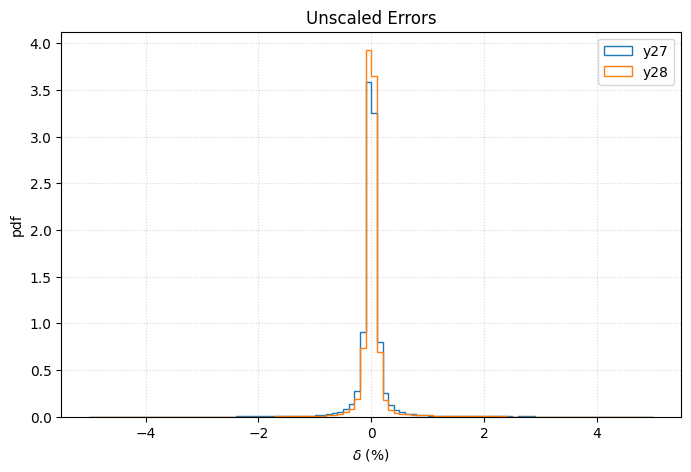

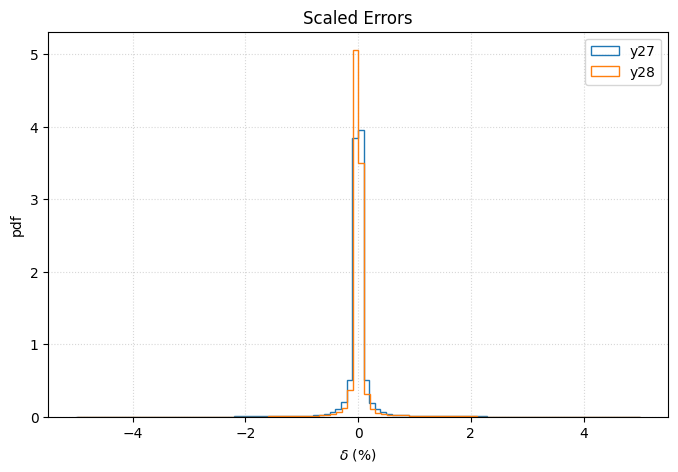

In [18]:
scaled_metrics, unscaled_metrics = evaluate_model(
    model, test_loader, get_device(), config, eps=0
)



=== Evaluation (SCALED) ===
Overall MAPE: 0.010405
Overall R2  : 0.999999
Overall Abs : 98.959548
y27: MAPE=0.010135, R2=0.999999, abs=98.986453
y28: MAPE=0.010674, R2=0.999999, abs=98.932642

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.010651
Overall R2  : 0.999999
Overall Abs : 98.934913
y27: MAPE=0.010373, R2=0.999999, abs=98.962705
y28: MAPE=0.010929, R2=0.999999, abs=98.907121


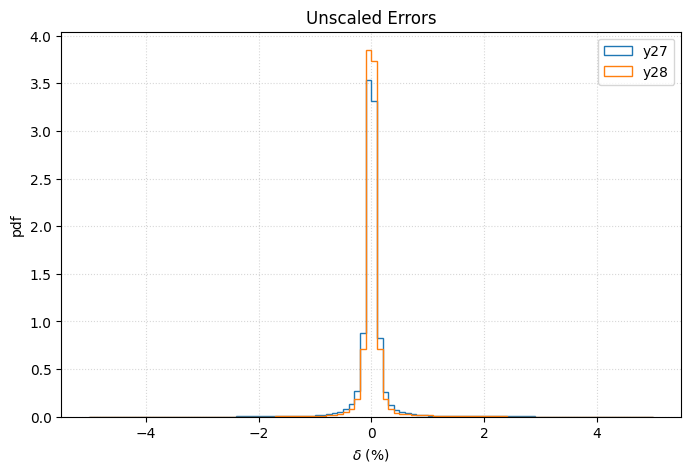

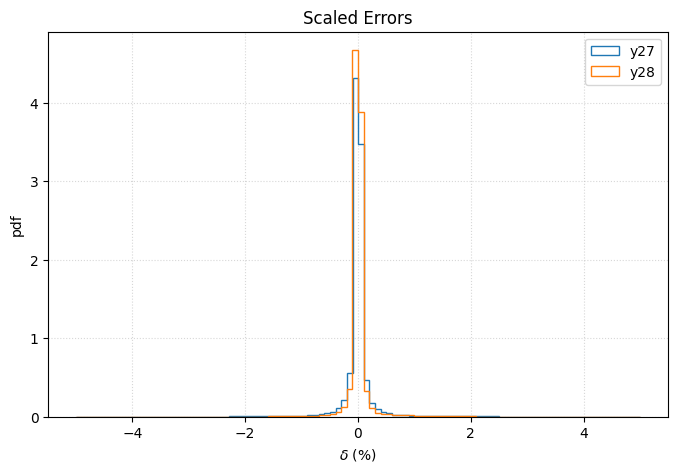

In [19]:
scaled_metrics, unscaled_metrics = evaluate_model(
    model, test_loader, get_device(), config, eps=1e-5
)



=== Evaluation (SCALED) ===
Overall MAPE: 0.023580
Overall R2  : 0.999999
Overall Abs : 97.641987
y27: MAPE=0.020825, R2=0.999999, abs=97.917504
y28: MAPE=0.026335, R2=0.999999, abs=97.366471

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.023830
Overall R2  : 0.999999
Overall Abs : 97.616996
y27: MAPE=0.021065, R2=0.999999, abs=97.893467
y28: MAPE=0.026595, R2=0.999999, abs=97.340525


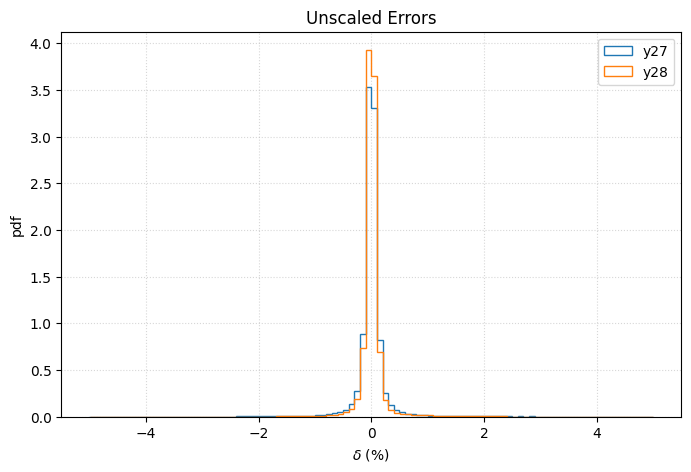

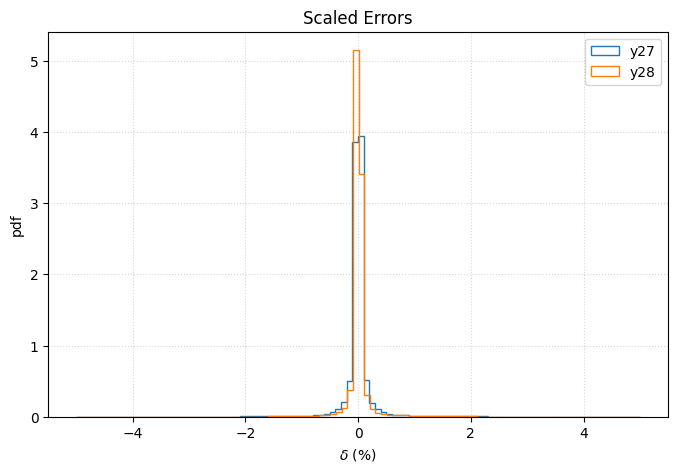

In [20]:
scaled_metrics, unscaled_metrics = evaluate_model(
    model, test_loader, get_device(), config, eps=1e-6
)



=== Evaluation (SCALED) ===
Overall MAPE: 0.058975
Overall R2  : 0.999999
Overall Abs : 94.102500
y27: MAPE=0.047653, R2=0.999999, abs=95.234710
y28: MAPE=0.070297, R2=0.999999, abs=92.970289

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.059235
Overall R2  : 0.999999
Overall Abs : 94.076505
y27: MAPE=0.047900, R2=0.999999, abs=95.209995
y28: MAPE=0.070570, R2=0.999999, abs=92.943015


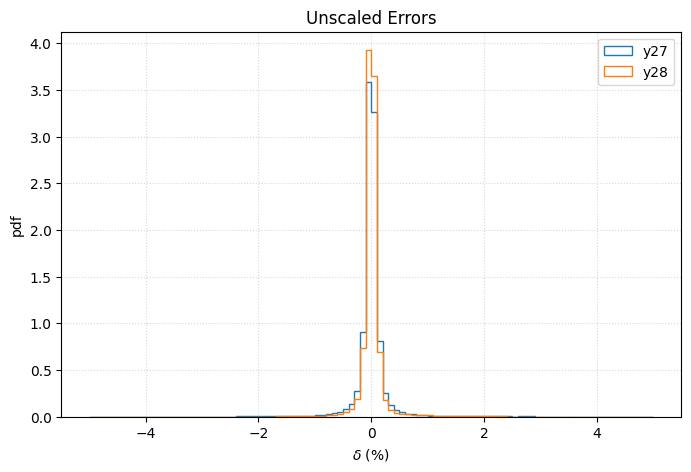

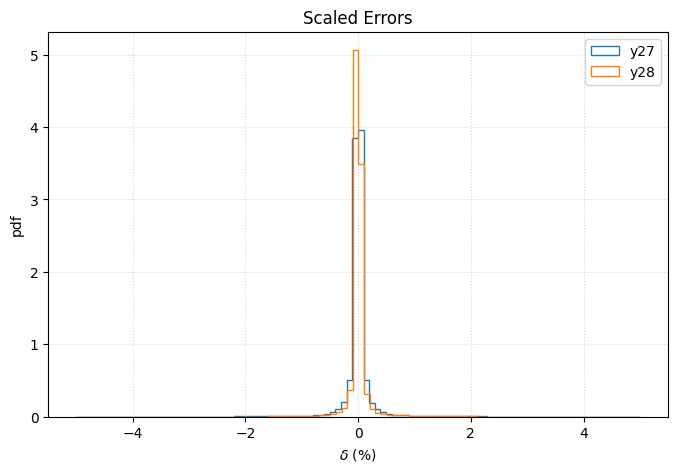

In [21]:
scaled_metrics, unscaled_metrics = evaluate_model(
    model, test_loader, get_device(), config, eps=1e-7
)


In [22]:
def filter_test_dataframe(df_split, target_cols, outlier_std=5.0):
    """
    Pre-inference filter for the test split.
    Swap the logic here if you want a different outlier rule later.
    """
    filtered_df = df_split.copy(deep=True)
    mask = pd.Series(True, index=filtered_df.index)

    for col in target_cols:
        mean = filtered_df[col].mean()
        std = filtered_df[col].std()
        if pd.notna(std) and std != 0:
            mask &= (filtered_df[col] - mean).abs() <= (outlier_std * std)

    filtered_df = filtered_df.loc[mask].reset_index(drop=True)
    return filtered_df


# Testing eval outlier removal

In [23]:
with pd.option_context('display.max_rows', None):
    display(
        df_pred.sort_values(by='scaled_delta_y27', key=lambda x: x.abs(), ascending=False).head(10)
    )


,x1,x2,x3,x4,y27_scaled,y28_scaled,y27,y28,y27_scaled_pred,y28_scaled_pred,y27_pred,y28_pred,scaled_delta_y27,scaled_delta_y28,delta_y27,delta_y28
24716,0.325617,2.691948e-07,0.536530,0.514836,-3.796401e-09,2.698135e-09,-3.796401e-09,2.698135e-09,0.000434,-0.000662,0.000434,-0.000662,-1.143674e+07,-2.453241e+07,-1.143922e+07,-2.454053e+07
245168,0.151820,1.198479e-06,0.524783,0.521728,-1.882473e-08,1.440584e-08,-1.882473e-08,1.440584e-08,0.000228,-0.000219,0.000228,-0.000219,-1.210052e+06,-1.520839e+06,-1.210190e+06,-1.521006e+06
438941,0.480303,1.452394e-06,0.503161,0.433968,-1.011544e-07,8.362084e-08,-1.011544e-07,8.362084e-08,0.000686,-0.000713,0.000686,-0.000713,-6.779884e+05,-8.522172e+05,-6.782209e+05,-8.525208e+05
484621,0.509094,2.420937e-06,0.547681,0.522653,-2.411088e-07,2.042408e-07,-2.411088e-07,2.042408e-07,0.000618,-0.000568,0.000618,-0.000568,-2.563140e+05,-2.780775e+05,-2.563931e+05,-2.781564e+05
412646,0.178360,6.884647e-06,0.523309,0.435041,-2.837789e-07,2.111543e-07,-2.837789e-07,2.111543e-07,0.000723,-0.000416,0.000724,-0.000416,-2.550382e+05,-1.969030e+05,-2.551304e+05,-1.969439e+05
316346,0.417806,1.224739e-06,0.431139,0.759019,-5.429658e-08,4.097301e-08,-5.429658e-08,4.097302e-08,-0.000083,-0.000714,-0.000083,-0.000715,1.522506e+05,-1.743463e+06,1.522569e+05,-1.744086e+06
390682,0.374474,5.354664e-06,0.478890,0.529459,-4.239484e-07,3.111428e-07,-4.239485e-07,3.111429e-07,0.000462,-0.000678,0.000462,-0.000679,-1.091271e+05,-2.180994e+05,-1.091523e+05,-2.181733e+05
309414,0.250150,1.018671e-05,0.553675,0.484256,-6.494228e-07,4.621333e-07,-6.494230e-07,4.621334e-07,0.000590,-0.000716,0.000590,-0.000717,-9.087812e+04,-1.551182e+05,-9.090486e+04,-1.551737e+05
442939,0.183831,1.766794e-05,0.512083,0.503621,-1.178510e-06,8.749825e-07,-1.178510e-06,8.749829e-07,0.000635,-0.000316,0.000635,-0.000316,-5.396257e+04,-3.625516e+04,-5.397964e+04,-3.626087e+04
11690,0.379167,1.074798e-05,0.515513,0.509512,-1.226581e-06,9.036049e-07,-1.226581e-06,9.036053e-07,0.000505,-0.000647,0.000505,-0.000647,-4.125345e+04,-7.170540e+04,-4.126381e+04,-7.172854e+04


In [24]:
with pd.option_context('display.max_rows', None):
    display(
        df_pred.sort_values(by='y27', key=lambda x: x.abs(), ascending=True).head(10)
    )


,x1,x2,x3,x4,y27_scaled,y28_scaled,y27,y28,y27_scaled_pred,y28_scaled_pred,y27_pred,y28_pred,scaled_delta_y27,scaled_delta_y28,delta_y27,delta_y28
24716,0.325617,2.691948e-07,0.536530,0.514836,-3.796401e-09,2.698135e-09,-3.796401e-09,2.698135e-09,0.000434,-0.000662,0.000434,-0.000662,-1.143674e+07,-2.453241e+07,-1.143922e+07,-2.454053e+07
245168,0.151820,1.198479e-06,0.524783,0.521728,-1.882473e-08,1.440584e-08,-1.882473e-08,1.440584e-08,0.000228,-0.000219,0.000228,-0.000219,-1.210052e+06,-1.520839e+06,-1.210190e+06,-1.521006e+06
316346,0.417806,1.224739e-06,0.431139,0.759019,-5.429658e-08,4.097301e-08,-5.429658e-08,4.097302e-08,-0.000083,-0.000714,-0.000083,-0.000715,1.522506e+05,-1.743463e+06,1.522569e+05,-1.744086e+06
438941,0.480303,1.452394e-06,0.503161,0.433968,-1.011544e-07,8.362084e-08,-1.011544e-07,8.362084e-08,0.000686,-0.000713,0.000686,-0.000713,-6.779884e+05,-8.522172e+05,-6.782209e+05,-8.525208e+05
484621,0.509094,2.420937e-06,0.547681,0.522653,-2.411088e-07,2.042408e-07,-2.411088e-07,2.042408e-07,0.000618,-0.000568,0.000618,-0.000568,-2.563140e+05,-2.780775e+05,-2.563931e+05,-2.781564e+05
412646,0.178360,6.884647e-06,0.523309,0.435041,-2.837789e-07,2.111543e-07,-2.837789e-07,2.111543e-07,0.000723,-0.000416,0.000724,-0.000416,-2.550382e+05,-1.969030e+05,-2.551304e+05,-1.969439e+05
390682,0.374474,5.354664e-06,0.478890,0.529459,-4.239484e-07,3.111428e-07,-4.239485e-07,3.111429e-07,0.000462,-0.000678,0.000462,-0.000679,-1.091271e+05,-2.180994e+05,-1.091523e+05,-2.181733e+05
309414,0.250150,1.018671e-05,0.553675,0.484256,-6.494228e-07,4.621333e-07,-6.494230e-07,4.621334e-07,0.000590,-0.000716,0.000590,-0.000717,-9.087812e+04,-1.551182e+05,-9.090486e+04,-1.551737e+05
421982,0.402873,6.602171e-06,0.514667,0.508391,-6.598647e-07,4.971372e-07,-6.598649e-07,4.971373e-07,0.000018,-0.000343,0.000018,-0.000343,-2.771699e+03,-6.918315e+04,-2.771722e+03,-6.919499e+04
497915,0.411605,7.243130e-06,0.563698,0.495425,-7.826313e-07,5.937030e-07,-7.826316e-07,5.937032e-07,0.000012,-0.000302,0.000012,-0.000302,-1.582412e+03,-5.090943e+04,-1.582420e+03,-5.091708e+04


In [25]:
import numpy as np

col = df_pred['y28']

# avoid log(0)
eps = 1e-12
log_vals = np.log10(np.abs(col) + eps)

# keep values within reasonable range
df_filtered = df_pred[(log_vals > -3) & (log_vals < 3)]

In [26]:
df_pred.sort_values(by=f'y27_scaled', key=lambda x: x.abs(), ascending=True).iloc[10:]


,x1,x2,x3,x4,y27_scaled,y28_scaled,y27,y28,y27_scaled_pred,y28_scaled_pred,y27_pred,y28_pred,scaled_delta_y27,scaled_delta_y28,delta_y27,delta_y28
442939,0.183831,0.000018,0.512083,0.503621,-0.000001,8.749825e-07,-0.000001,8.749829e-07,0.000635,-0.000316,0.000635,-0.000316,-53962.570124,-36255.163879,-53979.637316,-36260.867529
11690,0.379167,0.000011,0.515513,0.509512,-0.000001,9.036049e-07,-0.000001,9.036053e-07,0.000505,-0.000647,0.000505,-0.000647,-41253.449424,-71705.399969,-41263.812652,-71728.538022
60011,0.485074,0.000008,0.928431,0.562746,-0.000001,1.012104e-06,-0.000001,1.012104e-06,-0.000091,-0.000303,-0.000091,-0.000303,7125.184148,-30004.489333,7125.509028,-30009.000167
270646,0.405246,0.000011,0.615729,0.506799,-0.000001,1.069504e-06,-0.000001,1.069505e-06,0.000146,-0.000226,0.000146,-0.000226,-10324.942603,-21231.687835,-10325.679805,-21234.064639
328471,0.335082,0.000015,0.533851,0.520975,-0.000002,1.118556e-06,-0.000002,1.118557e-06,0.000150,-0.000507,0.000150,-0.000507,-9690.612502,-45424.470009,-9691.325519,-45435.935886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454952,0.663381,0.788818,0.274110,0.492448,1.902252,2.845735e+00,5.700967,1.621420e+01,1.902207,2.845749,5.700664,16.214454,-0.002380,0.000522,-0.005320,0.001577
76067,0.657658,0.742529,0.432086,0.523485,1.904763,2.807503e+00,5.717812,1.556849e+01,1.904175,2.807454,5.713865,15.567678,-0.030853,-0.001748,-0.069024,-0.005222
470085,0.663676,0.621565,0.523475,0.506569,1.916697,2.682193e+00,5.798463,1.361711e+01,1.917115,2.682710,5.801310,13.624680,0.021849,0.019292,0.049111,0.055560
60860,0.671776,0.594430,0.494662,0.539443,1.918017,2.648856e+00,5.807443,1.313786e+01,1.918150,2.648635,5.808353,13.134733,0.006969,-0.008347,0.015669,-0.023791


In [27]:
df_pred.sort_values(by=f'scaled_delta_y27', key=lambda x: x.abs(), ascending=False)

,x1,x2,x3,x4,y27_scaled,y28_scaled,y27,y28,y27_scaled_pred,y28_scaled_pred,y27_pred,y28_pred,scaled_delta_y27,scaled_delta_y28,delta_y27,delta_y28
24716,0.325617,2.691948e-07,0.536530,0.514836,-3.796401e-09,2.698135e-09,-3.796401e-09,2.698135e-09,0.000434,-0.000662,0.000434,-0.000662,-1.143674e+07,-2.453241e+07,-1.143922e+07,-2.454053e+07
245168,0.151820,1.198479e-06,0.524783,0.521728,-1.882473e-08,1.440584e-08,-1.882473e-08,1.440584e-08,0.000228,-0.000219,0.000228,-0.000219,-1.210052e+06,-1.520839e+06,-1.210190e+06,-1.521006e+06
438941,0.480303,1.452394e-06,0.503161,0.433968,-1.011544e-07,8.362084e-08,-1.011544e-07,8.362084e-08,0.000686,-0.000713,0.000686,-0.000713,-6.779884e+05,-8.522172e+05,-6.782209e+05,-8.525208e+05
484621,0.509094,2.420937e-06,0.547681,0.522653,-2.411088e-07,2.042408e-07,-2.411088e-07,2.042408e-07,0.000618,-0.000568,0.000618,-0.000568,-2.563140e+05,-2.780775e+05,-2.563931e+05,-2.781564e+05
412646,0.178360,6.884647e-06,0.523309,0.435041,-2.837789e-07,2.111543e-07,-2.837789e-07,2.111543e-07,0.000723,-0.000416,0.000724,-0.000416,-2.550382e+05,-1.969030e+05,-2.551304e+05,-1.969439e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318918,0.040951,8.836541e-01,0.525732,0.488895,-1.393160e+00,1.318217e+00,-3.027558e+00,2.736754e+00,-1.393160,1.317976,-3.027558,2.735853,-4.710823e-07,-1.828293e-02,-8.730662e-07,-3.290328e-02
457911,0.177094,5.529769e-01,0.511385,0.518230,-1.394475e+00,1.601572e+00,-3.032859e+00,3.960826e+00,-1.394475,1.601823,-3.032859,3.962069,4.074248e-07,1.564579e-02,7.554734e-07,3.138823e-02
102840,0.376283,7.426296e-01,0.515662,0.505047,-1.156460e+00,2.350474e+00,-2.178662e+00,9.490538e+00,-1.156460,2.350646,-2.178662,9.492341,3.921995e-07,7.309726e-03,6.617474e-07,1.899331e-02
83053,0.271940,3.149505e-01,0.519890,0.512478,-9.641064e-01,1.414971e+00,-1.622443e+00,3.116368e+00,-0.964106,1.415145,-1.622443,3.117083,-1.533636e-07,1.225830e-02,-2.389923e-07,2.291296e-02


In [28]:
col = 27
df_temp = df_pred.sort_values(by=f'y{col}_scaled', key=lambda x: x.abs(), ascending=True).iloc[0:]
temp_pred = df_temp[f"y{col}_scaled_pred"]
temp_test = df_temp[f"y{col}_scaled"]
1 - ((temp_pred - temp_test)/(temp_test)).abs().mean()

0.6988873378081544

In [29]:
col = 27
df_temp = df_pred.sort_values(by=f'y{col}_scaled', key=lambda x: x.abs(), ascending=True).iloc[1:]
temp_pred = df_temp[f"y{col}_scaled_pred"]
temp_test = df_temp[f"y{col}_scaled"]
1 - ((temp_pred - temp_test)/(temp_test)).abs().mean()

0.9277538255778783

In [30]:
col = 27
df_temp = df_pred.sort_values(by=f'y{col}_scaled', key=lambda x: x.abs(), ascending=True).iloc[2:]
temp_pred = df_temp[f"y{col}_scaled_pred"]
temp_test = df_temp[f"y{col}_scaled"]
1 - ((temp_pred - temp_test)/(temp_test)).abs().mean()

0.9519687620573297

In [31]:
col = 27
df_temp = df_pred.sort_values(by=f'y{col}_scaled', key=lambda x: x.abs(), ascending=True).iloc[3:]
temp_pred = df_temp[f"y{col}_scaled_pred"]
temp_test = df_temp[f"y{col}_scaled"]
1 - ((temp_pred - temp_test)/(temp_test)).abs().mean()

0.9550154519919271

In [32]:
col = 27
df_temp = df_pred.sort_values(by=f'y{col}_scaled', key=lambda x: x.abs(), ascending=True).iloc[4:]
temp_pred = df_temp[f"y{col}_scaled_pred"]
temp_test = df_temp[f"y{col}_scaled"]
1 - ((temp_pred - temp_test)/(temp_test)).abs().mean()

0.9685830541216641

In [33]:
col = 27
df_temp = df_pred.sort_values(by=f'y{col}_scaled', key=lambda x: x.abs(), ascending=True).iloc[10:]
temp_pred = df_temp[f"y{col}_scaled_pred"]
temp_test = df_temp[f"y{col}_scaled"]
1 - ((temp_pred - temp_test)/(temp_test)).abs().mean()

0.982905445328135

In [34]:
len(df_temp)

499702

In [35]:
df_pred.sort_values(by=f'y{col}_scaled', key=lambda x: x.abs(), ascending=True).iloc[499712:]

,x1,x2,x3,x4,y27_scaled,y28_scaled,y27,y28,y27_scaled_pred,y28_scaled_pred,y27_pred,y28_pred,scaled_delta_y27,scaled_delta_y28,delta_y27,delta_y28


In [36]:
col = 27
df_temp = df_pred.sort_values(by=f'y{col}_scaled', key=lambda x: x.abs(), ascending=True).iloc[499710:]
temp_pred = df_temp[f"y{col}_scaled_pred"]
temp_test = df_temp[f"y{col}_scaled"]
1 - ((temp_pred - temp_test)/(temp_test)).abs().mean()

0.9999629978972584

In [38]:
import numpy as np

df_temp = df_pred.copy()

eps = 1e-12

# log-scale for BOTH columns
log_y26 = np.log10(np.abs(df_temp['y26_scaled']) + eps)
log_y25 = np.log10(np.abs(df_temp['y25_scaled']) + eps)

# define bounds (you can tune this)
LOW, HIGH = -4, 4

# filter rows where BOTH are in reasonable range
mask = (
    (log_y26 > LOW) & (log_y26 < HIGH) &
    (log_y25 > LOW) & (log_y25 < HIGH)
)

df_temp = df_temp[mask]

# (optional) sort AFTER filtering
df_temp = df_temp.sort_values(
    by='y26_scaled',
    key=lambda x: x.abs(),
    ascending=False
)

# metric
temp_pred = df_temp["y26_scaled_pred"]
temp_test = df_temp["y26_scaled"]

score = 1 - ((temp_pred - temp_test) / temp_test).abs().mean()

before = len(df_pred)

df_filtered = df_pred[mask]

after = len(df_filtered)

removed = before - after
pct_removed = removed / before * 100

print(f"Removed: {removed} rows ({pct_removed:.2f}%)")

print(score)

KeyError: 'y26_scaled'

In [ ]:
import numpy as np

df_temp = df_pred.copy()

# --- Z-score filtering ---
cols = ['y26_scaled', 'y25_scaled']
THRESH = 6  # adjust if needed

mask = np.ones(len(df_temp), dtype=bool)

for col in cols:
    x = df_temp[col]
    z = (x - x.mean()) / x.std()
    mask &= z.abs() < THRESH

# --- apply filter ---
before = len(df_temp)
df_temp = df_temp[mask]
after = len(df_temp)

print(f"Removed: {before - after} rows ({(before - after)/before*100:.2f}%)")

# --- metric ---
temp_pred = df_temp["y26_scaled_pred"]
temp_test = df_temp["y26_scaled"]

# avoid division explosion near 0
nonzero_mask = np.abs(temp_test) > 1e-8

score = 1 - (
    ((temp_pred[nonzero_mask] - temp_test[nonzero_mask]) / temp_test[nonzero_mask])
    .abs()
    .mean()
)

print("Score:", score)

Removed: 7 rows (0.00%)
Score: 0.9887680649701606


# Ensembling

In [18]:
def filter_test_dataframe_std(df, cols, threshold=4.0, eps=1e-12):
    import numpy as np

    df_temp = df.copy()
    mask = np.ones(len(df_temp), dtype=bool)

    for col in cols:
        x = df_temp[col]

        std = x.std()
        if std < eps:  # avoid divide-by-zero
            continue

        z = (x - x.mean()) / std
        mask &= z.abs() < threshold  # strict (AND)

    return df_temp[mask]

In [19]:
def filter_test_dataframe_min_abs(df, cols, threshold=1e-8):
    import numpy as np

    df_temp = df.copy()
    mask = np.ones(len(df_temp), dtype=bool)

    for col in cols:
        x = df_temp[col]

        # Keep only rows where absolute value is NOT too small
        mask &= x.abs() > threshold  # strict AND across all columns

    return df_temp[mask]

In [21]:
pairs = [f"y{i}y{i+1}" for i in range(1, 35+1, 2)]
pairs

['y1y2',
 'y3y4',
 'y5y6',
 'y7y8',
 'y9y10',
 'y11y12',
 'y13y14',
 'y15y16',
 'y17y18',
 'y19y20',
 'y21y22',
 'y23y24',
 'y25y26',
 'y27y28',
 'y29y30',
 'y31y32',
 'y33y34',
 'y35y36']

In [23]:
# pairs = ["y25y26", "y27y28", "y7y8", "y11y12", "y3y4", "y5y6"]
for pair in pairs:
    ARTIFACT_ROOT = "./artifacts"
    DATA_DIR = "/scratch/akula.ha/dataset"
    MODEL_SEEDS = [1, 2, 3, 4, 5]

    pair_bootstrap_uuid = f"{pair}m{MODEL_SEEDS[0]}"
    _, pair_config = load_model_artifacts(pair_bootstrap_uuid, ARTIFACT_ROOT)
    pair_config["data_dir"] = DATA_DIR

    df, spark = load_data(pair_config)

    y_cols = pair_config["var_y"]
    test_df = df["test"].copy(deep=True)

    # scaled_cols = [f"{col}" for col in y_cols]
    # scaled_cols = [f"{col}_scaled" for col in y_cols]

    # for col, scol in zip(y_cols, scaled_cols):
    #     test_df[scol] = test_df[col].apply(y_scale)

    # for threshold in [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]:
    #     filtered = filter_test_dataframe_min_abs(test_df, cols=scaled_cols, threshold=threshold)
    #     removed = len(test_df) - len(filtered)
    #     print(f"threshold={threshold:<10}  |  {len(test_df)} -> {len(filtered)}  |  removed {removed} ({removed/len(test_df)*100:.2f}%)")
    scaled_cols = [f"{col}_scaled" for col in y_cols]
    for col, scol in zip(y_cols, scaled_cols):
        test_df[scol] = test_df[col].apply(y_scale)

    for label, cols in [("scaled", scaled_cols), ("unscaled", y_cols)]:
        print(f"\n--- Filtering on {label} columns: {cols} ---")
        for threshold in [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]:
            filtered = filter_test_dataframe_min_abs(test_df, cols=cols, threshold=threshold)
            removed = len(test_df) - len(filtered)
            print(f"  threshold={threshold:<10}  |  {len(test_df)} -> {len(filtered)}  |  removed {removed} ({removed/len(test_df)*100:.2f}%)")

[]
['y1', 'y2']



--- Filtering on scaled columns: ['y1_scaled', 'y2_scaled'] ---
  threshold=1e-09       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-08       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-07       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-06       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-05       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=0.0001      |  500000 -> 499997  |  removed 3 (0.00%)
  threshold=0.001       |  500000 -> 499986  |  removed 14 (0.00%)

--- Filtering on unscaled columns: ['y1', 'y2'] ---
  threshold=1e-09       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-08       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-07       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-06       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-05       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=0.0001      |  500000 -> 499997  |  removed 3 (0.00%)
  threshold=0.001      

[]
['y3', 'y4']



--- Filtering on scaled columns: ['y3_scaled', 'y4_scaled'] ---
  threshold=1e-09       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-08       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-07       |  500000 -> 499999  |  removed 1 (0.00%)
  threshold=1e-06       |  500000 -> 499998  |  removed 2 (0.00%)
  threshold=1e-05       |  500000 -> 499991  |  removed 9 (0.00%)
  threshold=0.0001      |  500000 -> 499901  |  removed 99 (0.02%)
  threshold=0.001       |  500000 -> 499030  |  removed 970 (0.19%)

--- Filtering on unscaled columns: ['y3', 'y4'] ---
  threshold=1e-09       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-08       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-07       |  500000 -> 499999  |  removed 1 (0.00%)
  threshold=1e-06       |  500000 -> 499998  |  removed 2 (0.00%)
  threshold=1e-05       |  500000 -> 499991  |  removed 9 (0.00%)
  threshold=0.0001      |  500000 -> 499901  |  removed 99 (0.02%)
  threshold=0.001   

[]
['y5', 'y6']


...


--- Filtering on scaled columns: ['y31_scaled', 'y32_scaled'] ---
  threshold=1e-09       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-08       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-07       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-06       |  500000 -> 499999  |  removed 1 (0.00%)
  threshold=1e-05       |  500000 -> 499992  |  removed 8 (0.00%)
  threshold=0.0001      |  500000 -> 499936  |  removed 64 (0.01%)
  threshold=0.001       |  500000 -> 499328  |  removed 672 (0.13%)

--- Filtering on unscaled columns: ['y31', 'y32'] ---
  threshold=1e-09       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-08       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-07       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-06       |  500000 -> 499999  |  removed 1 (0.00%)
  threshold=1e-05       |  500000 -> 499992  |  removed 8 (0.00%)
  threshold=0.0001      |  500000 -> 499936  |  removed 64 (0.01%)
  threshold=0.00

[]
['y33', 'y34']



--- Filtering on scaled columns: ['y33_scaled', 'y34_scaled'] ---
  threshold=1e-09       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-08       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-07       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-06       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-05       |  500000 -> 499999  |  removed 1 (0.00%)
  threshold=0.0001      |  500000 -> 499998  |  removed 2 (0.00%)
  threshold=0.001       |  500000 -> 499981  |  removed 19 (0.00%)

--- Filtering on unscaled columns: ['y33', 'y34'] ---
  threshold=1e-09       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-08       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-07       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-06       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-05       |  500000 -> 499999  |  removed 1 (0.00%)
  threshold=0.0001      |  500000 -> 499998  |  removed 2 (0.00%)
  threshold=0.001  

[]
['y35', 'y36']



--- Filtering on scaled columns: ['y35_scaled', 'y36_scaled'] ---
  threshold=1e-09       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-08       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-07       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-06       |  500000 -> 499999  |  removed 1 (0.00%)
  threshold=1e-05       |  500000 -> 499994  |  removed 6 (0.00%)
  threshold=0.0001      |  500000 -> 499904  |  removed 96 (0.02%)
  threshold=0.001       |  500000 -> 499004  |  removed 996 (0.20%)

--- Filtering on unscaled columns: ['y35', 'y36'] ---
  threshold=1e-09       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-08       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-07       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-06       |  500000 -> 499999  |  removed 1 (0.00%)
  threshold=1e-05       |  500000 -> 499994  |  removed 6 (0.00%)
  threshold=0.0001      |  500000 -> 499904  |  removed 96 (0.02%)
  threshold=0.00

In [ ]:
"""

--- Filtering on scaled columns: ['y35_scaled', 'y36_scaled'] ---
  threshold=1e-09       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-08       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-07       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-06       |  500000 -> 499999  |  removed 1 (0.00%)
  threshold=1e-05       |  500000 -> 499994  |  removed 6 (0.00%)
  threshold=0.0001      |  500000 -> 499904  |  removed 96 (0.02%)
  threshold=0.001       |  500000 -> 499004  |  removed 996 (0.20%)

--- Filtering on unscaled columns: ['y35', 'y36'] ---
  threshold=1e-09       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-08       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-07       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-06       |  500000 -> 499999  |  removed 1 (0.00%)
  threshold=1e-05       |  500000 -> 499994  |  removed 6 (0.00%)
  threshold=0.0001      |  500000 -> 499904  |  removed 96 (0.02%)
  threshold=0.001       |  500000 -> 499004  |  removed 996 (0.20%)

"""

In [49]:
pairs = ["y25y26", "y27y28", "y7y8", "y11y12", "y3y4", "y5y6"]
for pair in pairs:
    ARTIFACT_ROOT = "./artifacts"
    DATA_DIR = "/scratch/akula.ha/dataset"
    MODEL_SEEDS = [1, 2, 3, 4, 5]

    pair_bootstrap_uuid = f"{pair}m{MODEL_SEEDS[0]}"
    _, pair_config = load_model_artifacts(pair_bootstrap_uuid, ARTIFACT_ROOT)
    pair_config["data_dir"] = DATA_DIR

    df, spark = load_data(pair_config)

    y_cols = pair_config["var_y"]
    test_df = df["test"].copy(deep=True)

    # scaled_cols = [f"{col}" for col in y_cols]
    # scaled_cols = [f"{col}_scaled" for col in y_cols]

    # for col, scol in zip(y_cols, scaled_cols):
    #     test_df[scol] = test_df[col].apply(y_scale)

    # for threshold in [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]:
    #     filtered = filter_test_dataframe_min_abs(test_df, cols=scaled_cols, threshold=threshold)
    #     removed = len(test_df) - len(filtered)
    #     print(f"threshold={threshold:<10}  |  {len(test_df)} -> {len(filtered)}  |  removed {removed} ({removed/len(test_df)*100:.2f}%)")
    scaled_cols = [f"{col}_scaled" for col in y_cols]
    for col, scol in zip(y_cols, scaled_cols):
        test_df[scol] = test_df[col].apply(y_scale)

    for label, cols in [("scaled", scaled_cols), ("unscaled", y_cols)]:
        print(f"\n--- Filtering on {label} columns: {cols} ---")
        for threshold in [1e-7, 1e-6, 1e-5, 1e-4, 1e-3]:
            filtered = filter_test_dataframe_min_abs(test_df, cols=cols, threshold=threshold)
            removed = len(test_df) - len(filtered)
            print(f"  threshold={threshold:<10}  |  {len(test_df)} -> {len(filtered)}  |  removed {removed} ({removed/len(test_df)*100:.2f}%)")


[]
['y25', 'y26']



--- Filtering on scaled columns: ['y25_scaled', 'y26_scaled'] ---
  threshold=1e-07       |  500000 -> 499999  |  removed 1 (0.00%)
  threshold=1e-06       |  500000 -> 499998  |  removed 2 (0.00%)
  threshold=1e-05       |  500000 -> 499996  |  removed 4 (0.00%)
  threshold=0.0001      |  500000 -> 499989  |  removed 11 (0.00%)
  threshold=0.001       |  500000 -> 499931  |  removed 69 (0.01%)

--- Filtering on unscaled columns: ['y25', 'y26'] ---
  threshold=1e-07       |  500000 -> 499999  |  removed 1 (0.00%)
  threshold=1e-06       |  500000 -> 499998  |  removed 2 (0.00%)
  threshold=1e-05       |  500000 -> 499996  |  removed 4 (0.00%)
  threshold=0.0001      |  500000 -> 499989  |  removed 11 (0.00%)
  threshold=0.001       |  500000 -> 499931  |  removed 69 (0.01%)


[]
['y27', 'y28']



--- Filtering on scaled columns: ['y27_scaled', 'y28_scaled'] ---
  threshold=1e-07       |  500000 -> 499996  |  removed 4 (0.00%)
  threshold=1e-06       |  500000 -> 499988  |  removed 12 (0.00%)
  threshold=1e-05       |  500000 -> 499938  |  removed 62 (0.01%)
  threshold=0.0001      |  500000 -> 499687  |  removed 313 (0.06%)
  threshold=0.001       |  500000 -> 498375  |  removed 1625 (0.33%)

--- Filtering on unscaled columns: ['y27', 'y28'] ---
  threshold=1e-07       |  500000 -> 499996  |  removed 4 (0.00%)
  threshold=1e-06       |  500000 -> 499988  |  removed 12 (0.00%)
  threshold=1e-05       |  500000 -> 499938  |  removed 62 (0.01%)
  threshold=0.0001      |  500000 -> 499687  |  removed 313 (0.06%)
  threshold=0.001       |  500000 -> 498375  |  removed 1625 (0.33%)


[]
['y7', 'y8']


...


--- Filtering on scaled columns: ['y11_scaled', 'y12_scaled'] ---
  threshold=1e-07       |  500000 -> 499997  |  removed 3 (0.00%)
  threshold=1e-06       |  500000 -> 499984  |  removed 16 (0.00%)
  threshold=1e-05       |  500000 -> 499936  |  removed 64 (0.01%)
  threshold=0.0001      |  500000 -> 499674  |  removed 326 (0.07%)
  threshold=0.001       |  500000 -> 498373  |  removed 1627 (0.33%)

--- Filtering on unscaled columns: ['y11', 'y12'] ---
  threshold=1e-07       |  500000 -> 499997  |  removed 3 (0.00%)
  threshold=1e-06       |  500000 -> 499984  |  removed 16 (0.00%)
  threshold=1e-05       |  500000 -> 499936  |  removed 64 (0.01%)
  threshold=0.0001      |  500000 -> 499674  |  removed 326 (0.07%)
  threshold=0.001       |  500000 -> 498373  |  removed 1627 (0.33%)


[]
['y3', 'y4']



--- Filtering on scaled columns: ['y3_scaled', 'y4_scaled'] ---
  threshold=1e-07       |  500000 -> 499999  |  removed 1 (0.00%)
  threshold=1e-06       |  500000 -> 499998  |  removed 2 (0.00%)
  threshold=1e-05       |  500000 -> 499991  |  removed 9 (0.00%)
  threshold=0.0001      |  500000 -> 499901  |  removed 99 (0.02%)
  threshold=0.001       |  500000 -> 499030  |  removed 970 (0.19%)

--- Filtering on unscaled columns: ['y3', 'y4'] ---
  threshold=1e-07       |  500000 -> 499999  |  removed 1 (0.00%)
  threshold=1e-06       |  500000 -> 499998  |  removed 2 (0.00%)
  threshold=1e-05       |  500000 -> 499991  |  removed 9 (0.00%)
  threshold=0.0001      |  500000 -> 499901  |  removed 99 (0.02%)
  threshold=0.001       |  500000 -> 499030  |  removed 970 (0.19%)


[]
['y5', 'y6']



--- Filtering on scaled columns: ['y5_scaled', 'y6_scaled'] ---
  threshold=1e-07       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-06       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-05       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=0.0001      |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=0.001       |  500000 -> 499992  |  removed 8 (0.00%)

--- Filtering on unscaled columns: ['y5', 'y6'] ---
  threshold=1e-07       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-06       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=1e-05       |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=0.0001      |  500000 -> 500000  |  removed 0 (0.00%)
  threshold=0.001       |  500000 -> 499992  |  removed 8 (0.00%)



################################################################################
Preparing evaluation pipeline for pair: y25y26
Seeds to evaluate: [1, 2, 3, 4, 5]
################################################################################


Loading dataset for y25y26 using bootstrap model y25y26m1


[]
['y25', 'y26']


y25y26: 500000 -> 486258 (13742 removed, 2.75%)
y25y26: filtered test rows 500000 -> 486258 using 4.3 std
Building shared test loader for y25y26

Running single-model evaluation for y25y26m1


/tmp/ipykernel_1860833/2024034432.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y25y26m1

=== Evaluation (SCALED) ===
Overall MAPE: 0.000197
Overall R2  : 0.999956
Overall Abs : 99.980316
y25: MAPE=0.000182, R2=0.999971, abs=99.981833
y26: MAPE=0.000212, R2=0.999941, abs=99.978798

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.000938
Overall R2  : 0.999865
Overall Abs : 99.906200
y25: MAPE=0.000878, R2=0.999736, abs=99.912228
y26: MAPE=0.000998, R2=0.999994, abs=99.900173


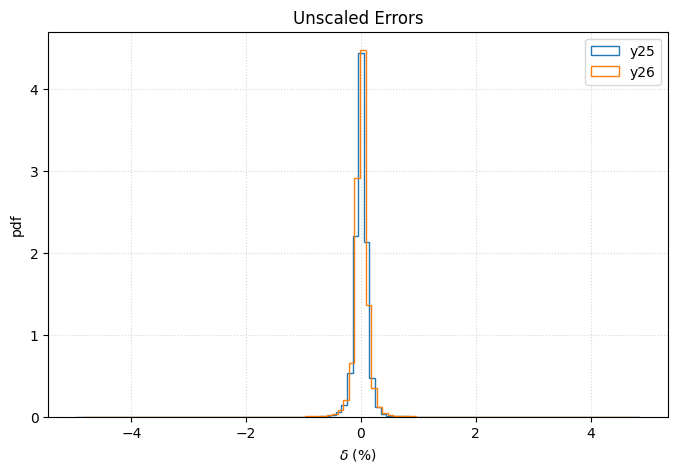

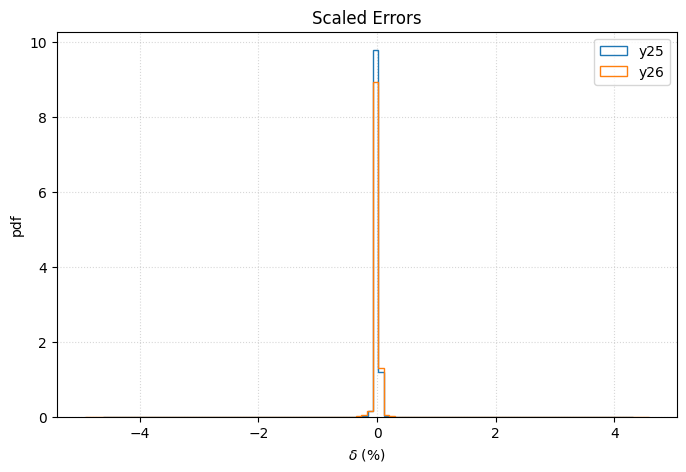

Completed single-model evaluation for y25y26m1

Running single-model evaluation for y25y26m2


/tmp/ipykernel_1860833/2024034432.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y25y26m2

=== Evaluation (SCALED) ===
Overall MAPE: 0.000198
Overall R2  : 0.999957
Overall Abs : 99.980158
y25: MAPE=0.000187, R2=0.999972, abs=99.981250
y26: MAPE=0.000209, R2=0.999943, abs=99.979066

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.000965
Overall R2  : 0.999767
Overall Abs : 99.903511
y25: MAPE=0.000919, R2=0.999544, abs=99.908130
y26: MAPE=0.001011, R2=0.999991, abs=99.898892


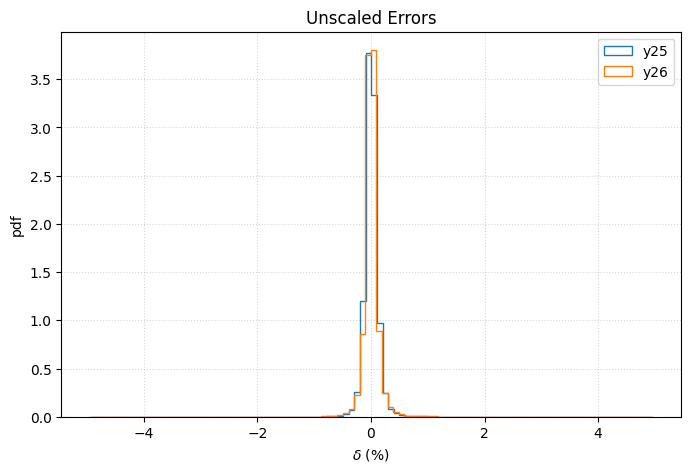

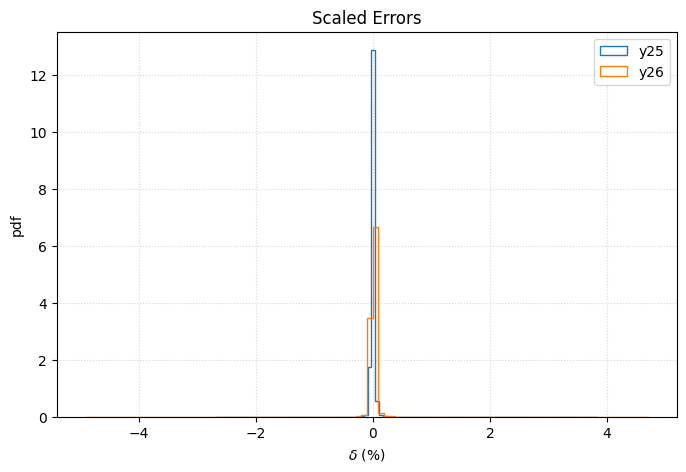

Completed single-model evaluation for y25y26m2

Running single-model evaluation for y25y26m3


/tmp/ipykernel_1860833/2024034432.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y25y26m3

=== Evaluation (SCALED) ===
Overall MAPE: 0.000204
Overall R2  : 0.999946
Overall Abs : 99.979623
y25: MAPE=0.000188, R2=0.999963, abs=99.981151
y26: MAPE=0.000219, R2=0.999929, abs=99.978094

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.001001
Overall R2  : 0.999738
Overall Abs : 99.899887
y25: MAPE=0.000934, R2=0.999485, abs=99.906580
y26: MAPE=0.001068, R2=0.999991, abs=99.893193


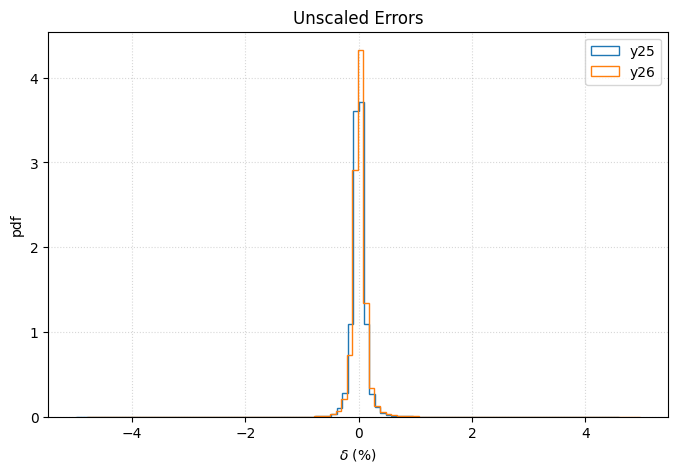

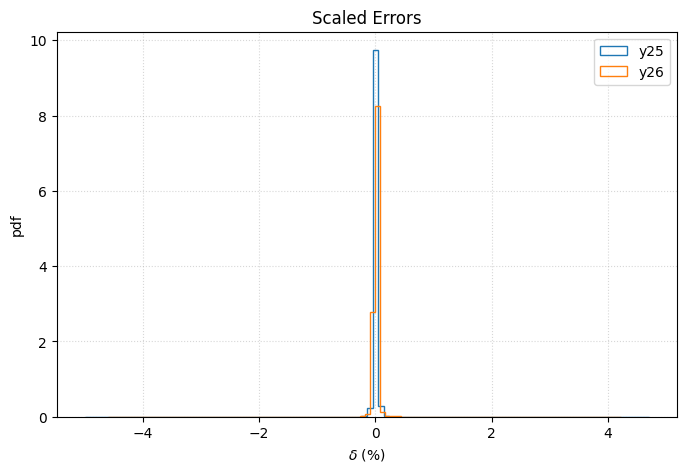

Completed single-model evaluation for y25y26m3

Running single-model evaluation for y25y26m4


/tmp/ipykernel_1860833/2024034432.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y25y26m4

=== Evaluation (SCALED) ===
Overall MAPE: 0.000218
Overall R2  : 0.999946
Overall Abs : 99.978162
y25: MAPE=0.000206, R2=0.999963, abs=99.979418
y26: MAPE=0.000231, R2=0.999930, abs=99.976905

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.001080
Overall R2  : 0.999793
Overall Abs : 99.892046
y25: MAPE=0.001022, R2=0.999598, abs=99.897798
y26: MAPE=0.001137, R2=0.999989, abs=99.886294


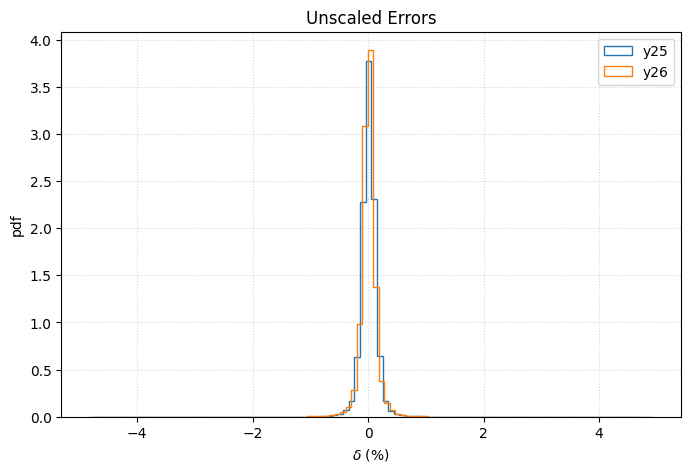

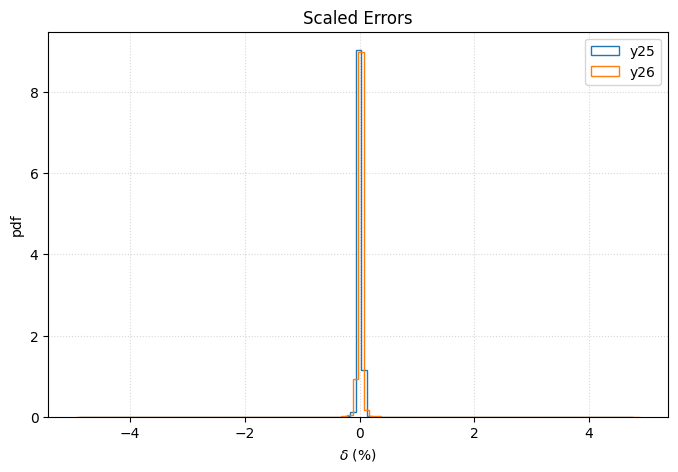

Completed single-model evaluation for y25y26m4

Running single-model evaluation for y25y26m5


/tmp/ipykernel_1860833/2024034432.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y25y26m5

=== Evaluation (SCALED) ===
Overall MAPE: 0.000194
Overall R2  : 0.999952
Overall Abs : 99.980617
y25: MAPE=0.000184, R2=0.999966, abs=99.981610
y26: MAPE=0.000204, R2=0.999939, abs=99.979623

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.000953
Overall R2  : 0.999815
Overall Abs : 99.904693
y25: MAPE=0.000910, R2=0.999638, abs=99.909017
y26: MAPE=0.000996, R2=0.999993, abs=99.900370


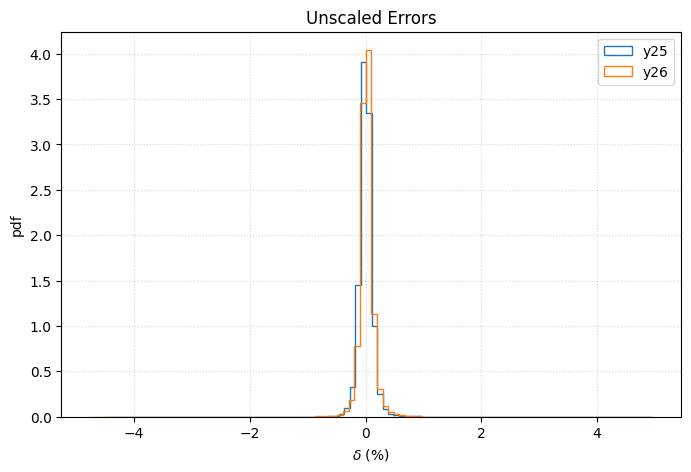

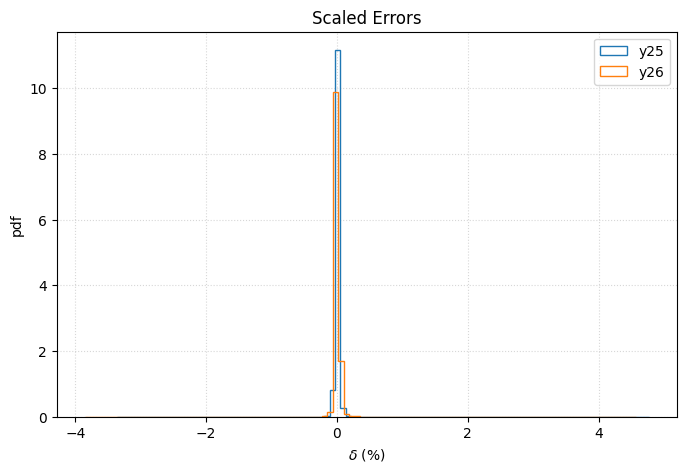

Completed single-model evaluation for y25y26m5

Running ensemble evaluation for pair y25y26

################################################################################
Starting ensemble evaluation for targets: ['y25', 'y26']
Using 5 checkpoints
################################################################################


/tmp/ipykernel_1860833/4202110712.py:131: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.000101
Overall R2  : 0.999957
Overall Abs : 99.989857
y25: MAPE=0.000091, R2=0.999972, abs=99.990882
y26: MAPE=0.000112, R2=0.999942, abs=99.988832

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.000514
Overall R2  : 0.999829
Overall Abs : 99.948644
y25: MAPE=0.000461, R2=0.999661, abs=99.953913
y26: MAPE=0.000566, R2=0.999996, abs=99.943374


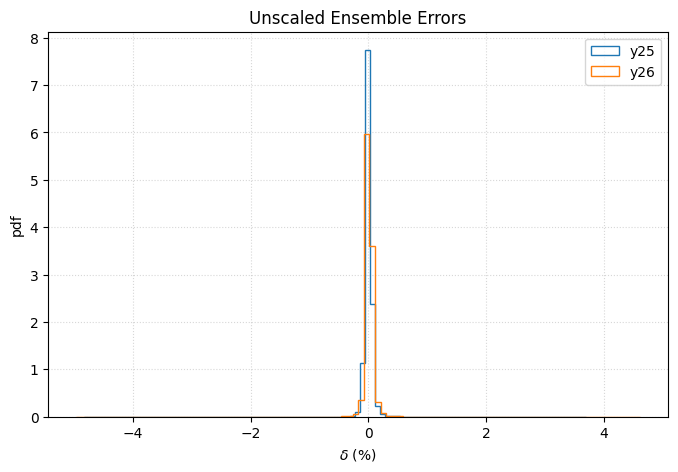

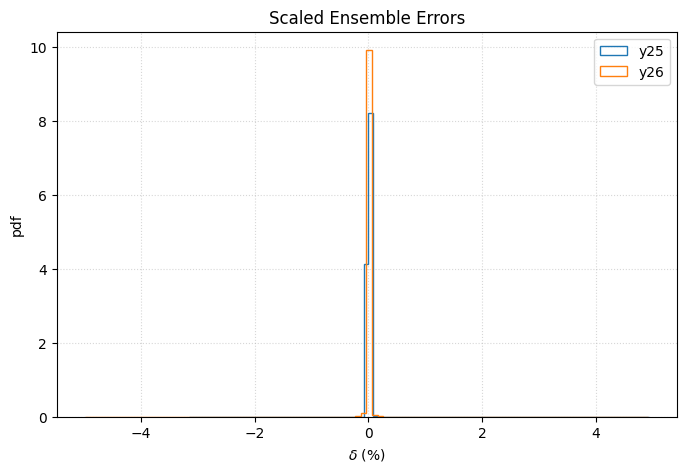

Completed all evaluations for pair y25y26

################################################################################
Preparing evaluation pipeline for pair: y27y28
Seeds to evaluate: [1, 2, 3, 4, 5]
################################################################################


Loading dataset for y27y28 using bootstrap model y27y28m1


[]
['y27', 'y28']


y27y28: 500000 -> 493758 (6242 removed, 1.25%)
y27y28: filtered test rows 500000 -> 493758 using 4.3 std
Building shared test loader for y27y28

Running single-model evaluation for y27y28m1


/tmp/ipykernel_1860833/2024034432.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y27y28m1

=== Evaluation (SCALED) ===
Overall MAPE: 0.463475
Overall R2  : 0.999999
Overall Abs : 53.652527
y27: MAPE=0.304742, R2=0.999998, abs=69.525817
y28: MAPE=0.622208, R2=0.999999, abs=37.779236

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.463851
Overall R2  : 0.999999
Overall Abs : 53.614893
y27: MAPE=0.305043, R2=0.999998, abs=69.495666
y28: MAPE=0.622659, R2=0.999999, abs=37.734120


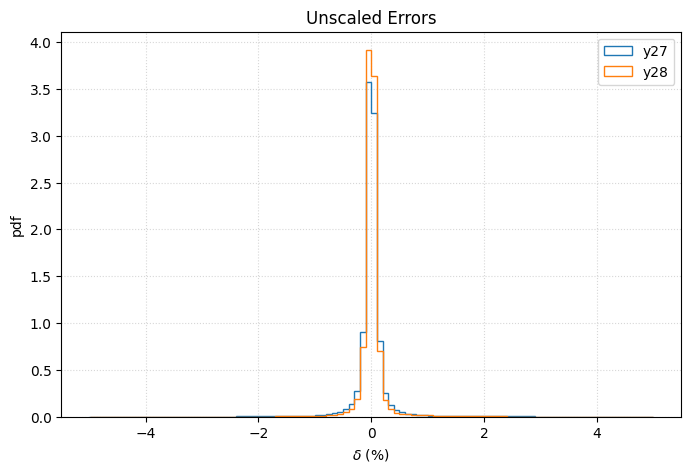

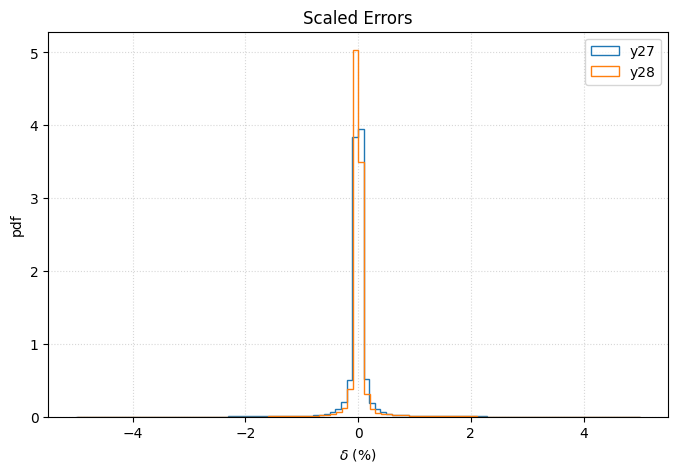

Completed single-model evaluation for y27y28m1

Running single-model evaluation for y27y28m2


/tmp/ipykernel_1860833/2024034432.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y27y28m2

=== Evaluation (SCALED) ===
Overall MAPE: 0.207331
Overall R2  : 0.999999
Overall Abs : 79.266871
y27: MAPE=0.183975, R2=0.999999, abs=81.602501
y28: MAPE=0.230688, R2=0.999999, abs=76.931241

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.207578
Overall R2  : 0.999999
Overall Abs : 79.242200
y27: MAPE=0.184202, R2=0.999999, abs=81.579792
y28: MAPE=0.230954, R2=0.999999, abs=76.904609


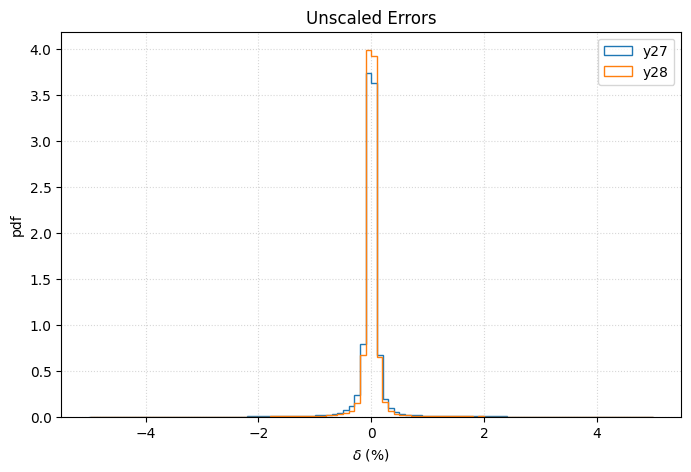

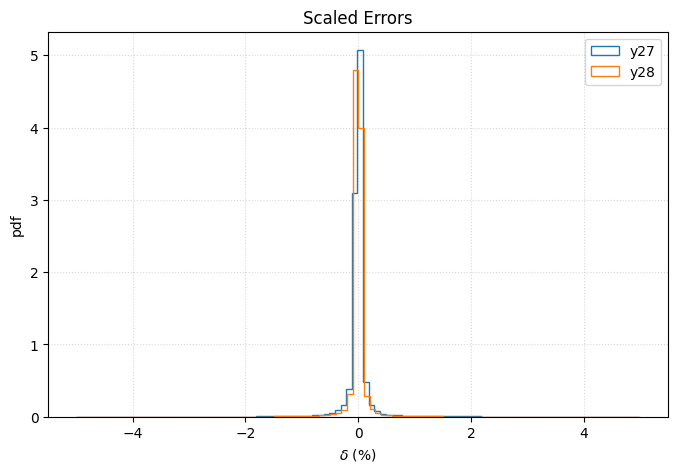

Completed single-model evaluation for y27y28m2

Running single-model evaluation for y27y28m3


/tmp/ipykernel_1860833/2024034432.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y27y28m3

=== Evaluation (SCALED) ===
Overall MAPE: 0.161892
Overall R2  : 0.999999
Overall Abs : 83.810837
y27: MAPE=0.141402, R2=0.999999, abs=85.859801
y28: MAPE=0.182381, R2=0.999999, abs=81.761873

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.162143
Overall R2  : 0.999999
Overall Abs : 83.785706
y27: MAPE=0.141641, R2=0.999999, abs=85.835937
y28: MAPE=0.182645, R2=0.999999, abs=81.735474


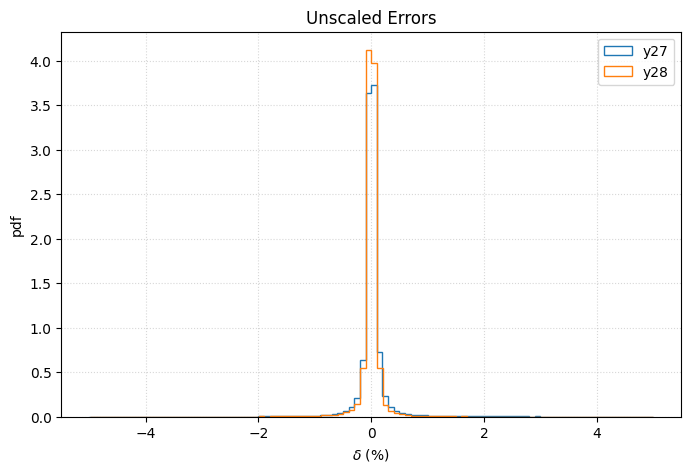

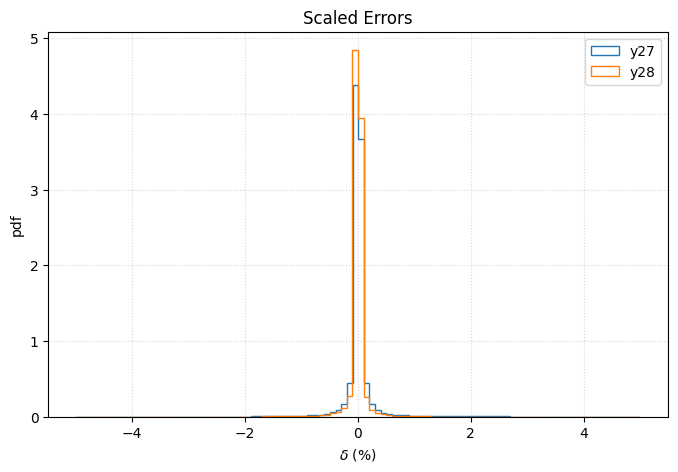

Completed single-model evaluation for y27y28m3

Running single-model evaluation for y27y28m4


/tmp/ipykernel_1860833/2024034432.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y27y28m4

=== Evaluation (SCALED) ===
Overall MAPE: 0.418775
Overall R2  : 0.999999
Overall Abs : 58.122521
y27: MAPE=0.378013, R2=0.999999, abs=62.198704
y28: MAPE=0.459537, R2=0.999999, abs=54.046339

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.419083
Overall R2  : 0.999999
Overall Abs : 58.091652
y27: MAPE=0.378304, R2=0.999999, abs=62.169594
y28: MAPE=0.459863, R2=0.999999, abs=54.013710


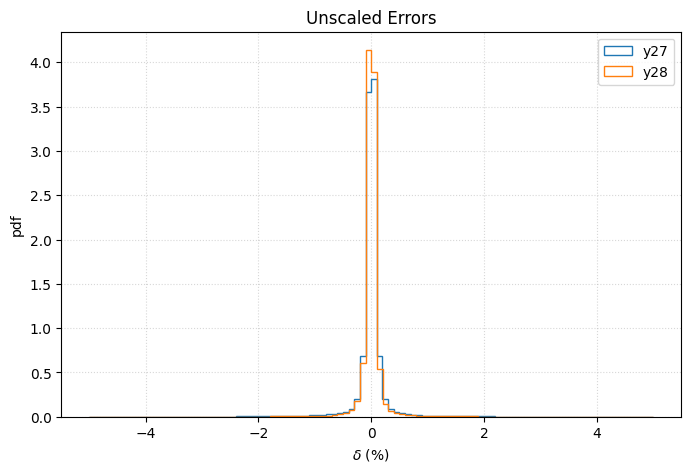

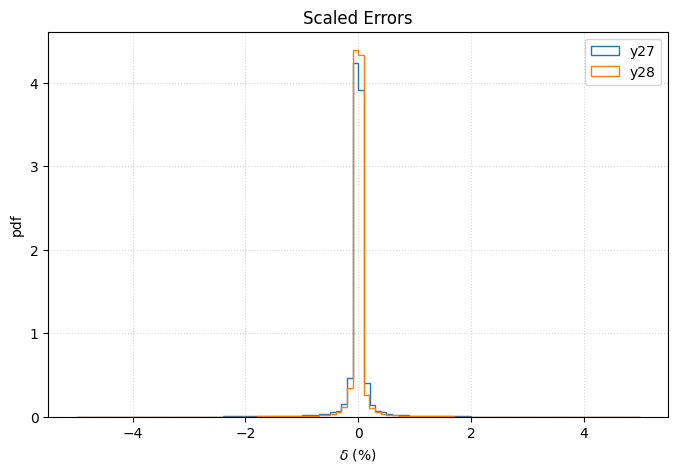

Completed single-model evaluation for y27y28m4

Running single-model evaluation for y27y28m5


/tmp/ipykernel_1860833/2024034432.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y27y28m5

=== Evaluation (SCALED) ===
Overall MAPE: 0.247624
Overall R2  : 0.999999
Overall Abs : 75.237589
y27: MAPE=0.279572, R2=0.999999, abs=72.042779
y28: MAPE=0.215676, R2=0.999999, abs=78.432399

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.247882
Overall R2  : 0.999999
Overall Abs : 75.211837
y27: MAPE=0.279834, R2=0.999999, abs=72.016644
y28: MAPE=0.215930, R2=0.999999, abs=78.407030


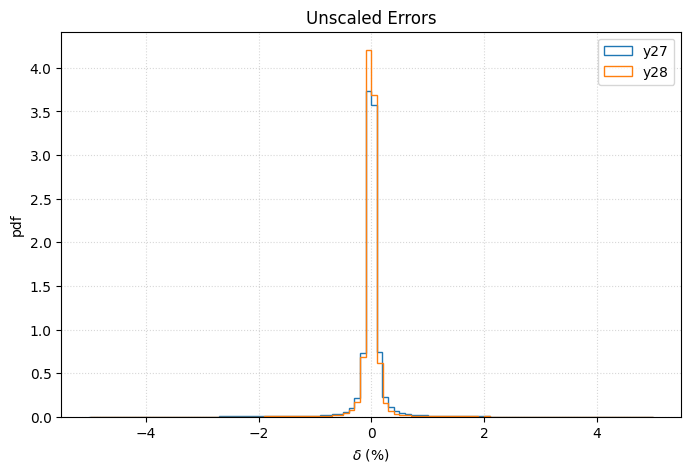

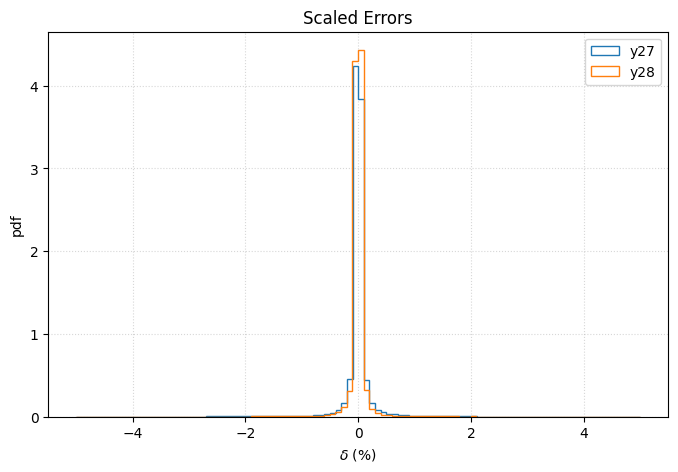

Completed single-model evaluation for y27y28m5

Running ensemble evaluation for pair y27y28

################################################################################
Starting ensemble evaluation for targets: ['y27', 'y28']
Using 5 checkpoints
################################################################################


/tmp/ipykernel_1860833/4202110712.py:131: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.253367
Overall R2  : 1.000000
Overall Abs : 74.663318
y27: MAPE=0.192546, R2=1.000000, abs=80.745353
y28: MAPE=0.314187, R2=1.000000, abs=68.581284

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.253507
Overall R2  : 1.000000
Overall Abs : 74.649319
y27: MAPE=0.192669, R2=1.000000, abs=80.733078
y28: MAPE=0.314344, R2=1.000000, abs=68.565561


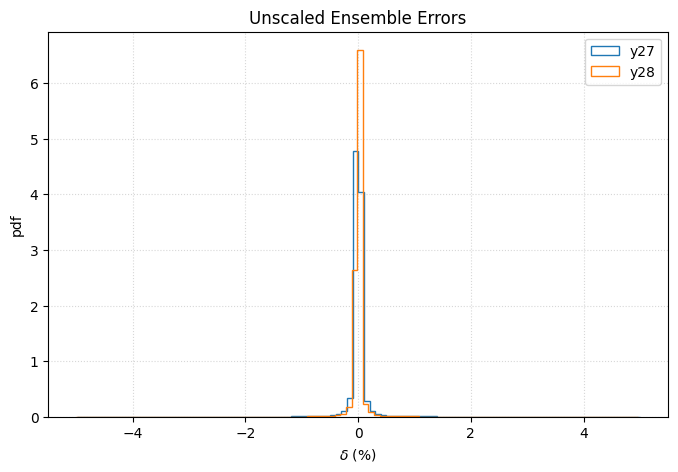

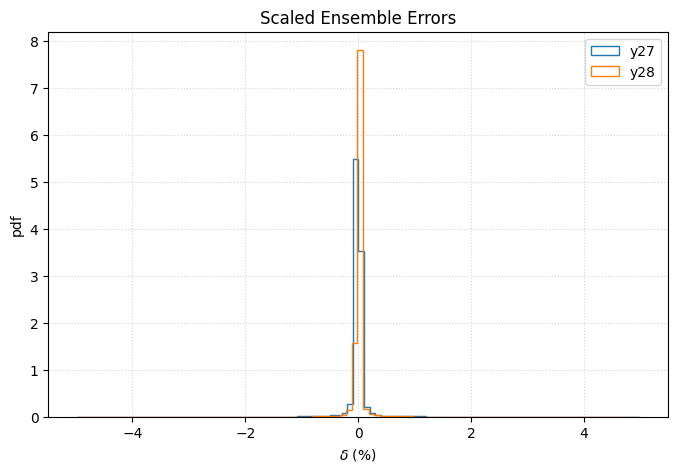

Completed all evaluations for pair y27y28


In [ ]:
MODEL_PAIRS = ["y25y26"] #, "y27y28"] #, "y7y8", "y11y12", "y3y4"]
MODEL_SEEDS = [1, 2, 3, 4, 5]
ARTIFACT_ROOT = "./artifacts"
DATA_DIR = "/scratch/akula.ha/dataset"
OUTLIER_STD = 4.3

all_results = {}

for pair in MODEL_PAIRS:
    print(f"\n{'#' * 80}")
    print(f"Preparing evaluation pipeline for pair: {pair}")
    print(f"Seeds to evaluate: {MODEL_SEEDS}")
    print(f"{'#' * 80}")

    pair_bootstrap_uuid = f"{pair}m{MODEL_SEEDS[0]}"
    _, pair_config = load_model_artifacts(pair_bootstrap_uuid, ARTIFACT_ROOT)
    pair_config["data_dir"] = DATA_DIR

    print(f"Loading dataset for {pair} using bootstrap model {pair_bootstrap_uuid}")
    df, spark = load_data(pair_config)

    x_cols = ['x1', 'x2', 'x3', 'x4']
    y_cols = pair_config["var_y"]

    test_df = df["test"].copy(deep=True)
    # filtered_test_df = filter_test_dataframe(
    #     test_df,
    #     y_cols,
    #     outlier_std=OUTLIER_STD,
    # )
    # filtered_test_df = filter_test_dataframe_std(
    #     test_df,
    #     cols=y_cols,  # or y_cols
    #     threshold=OUTLIER_STD,
    # )

    # create scaled versions dynamically
    scaled_cols = [f"{col}_scaled" for col in y_cols]

    for col, scol in zip(y_cols, scaled_cols):
        test_df[scol] = test_df[col].apply(y_scale)

    # filter using scaled cols
    # filtered_test_df = filter_test_dataframe_std(
    #     test_df,
    #     cols=scaled_cols,
    #     threshold=3,
    # )
    filtered_test_df = filter_test_dataframe_min_abs(
        test_df,
        cols=scaled_cols,  # or y_cols depending on what you want
        threshold=1e-5,
    )
    before = len(test_df)
    after = len(filtered_test_df)

    print(f"{pair}: {before} -> {after} ({before - after} removed, {(before-after)/before*100:.2f}%)")
    print(
        f"{pair}: filtered test rows {len(test_df)} -> {len(filtered_test_df)} "
        f"using {OUTLIER_STD} std"
    )
    print(f"Building shared test loader for {pair}")

    pair_test_dataset = MyDataset(
        filtered_test_df[x_cols],
        filtered_test_df[y_cols],
        pair_config,
    )
    batch_size = pair_config["batch_size"]
    numworkers = 4 if get_device().type == 'cpu' else 0
    pair_test_loader = torch.utils.data.DataLoader(
        pair_test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=numworkers,
        drop_last=False,
    )

    all_results[pair] = {}
    pair_checkpoint_paths = []

    for seed in MODEL_SEEDS:
        model_uuid = f"{pair}m{seed}"
        print(f"\n{'=' * 80}")
        print(f"Running single-model evaluation for {model_uuid}")
        print(f"{'=' * 80}")

        weights_path, seed_config = load_model_artifacts(model_uuid, ARTIFACT_ROOT)
        seed_config["data_dir"] = DATA_DIR
        pair_checkpoint_paths.append(weights_path)
        print(f"Loaded artifacts for {model_uuid}")

        width = seed_config['width']
        depth = seed_config['depth']
        n_skip_layers = seed_config['skip_block_layers']
        activation = seed_config['activation']

        seed_model = SkipModel(
            seed_config["input_shape"],
            width,
            depth,
            n_skip_layers,
            len(seed_config["var_y"]),
            activation,
        )
        seed_model.to(device=get_device())
        seed_model.load_state_dict(
            torch.load(
                weights_path,
                map_location=torch.device(
                    'cuda' if torch.cuda.is_available() else 'cpu'
                ),
            )
        )

        test_metrics, df_pred = test_model(seed_model, pair_test_loader, seed_config)
        scaled_metrics, unscaled_metrics = evaluate_model(
            seed_model, pair_test_loader, get_device(), seed_config, eps=0
        )
        print(f"Completed single-model evaluation for {model_uuid}")

        all_results[pair][seed] = {
            "model_uuid": model_uuid,
            "config": seed_config,
            "filtered_test_df": filtered_test_df.copy(deep=True),
            "test_metrics": test_metrics,
            "scaled_metrics": scaled_metrics,
            "unscaled_metrics": unscaled_metrics,
            "df_pred": df_pred,
        }

    print(f"\n{'=' * 80}")
    print(f"Running ensemble evaluation for pair {pair}")
    print(f"{'=' * 80}")
    all_results[pair]["ensemble"] = run_ensemble_evaluation(
        test_df=filtered_test_df,
        checkpoint_paths=pair_checkpoint_paths,
        config=pair_config,
        dataloader=pair_test_loader,
        eps=0,
    )
    print(f"Completed all evaluations for pair {pair}")



################################################################################
Preparing evaluation pipeline for pair: y25y26
Seeds to evaluate: [1, 2, 3, 4, 5]
################################################################################


Loading dataset for y25y26 using bootstrap model y25y26m1


[]
['y25', 'y26']


y25y26: 500000 -> 499996 (4 removed, 0.00%)
y25y26: filtered test rows 500000 -> 499996 
Building shared test loader for y25y26

Running single-model evaluation for y25y26m1


/tmp/ipykernel_1860833/3287956048.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y25y26m1

=== Evaluation (SCALED) ===
Overall MAPE: 0.001189
Overall R2  : 0.999955
Overall Abs : 99.881098
y25: MAPE=0.000425, R2=0.999970, abs=99.957505
y26: MAPE=0.001953, R2=0.999940, abs=99.804691

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.001989
Overall R2  : 0.999928
Overall Abs : 99.801136
y25: MAPE=0.001172, R2=0.999885, abs=99.882841
y26: MAPE=0.002806, R2=0.999971, abs=99.719431


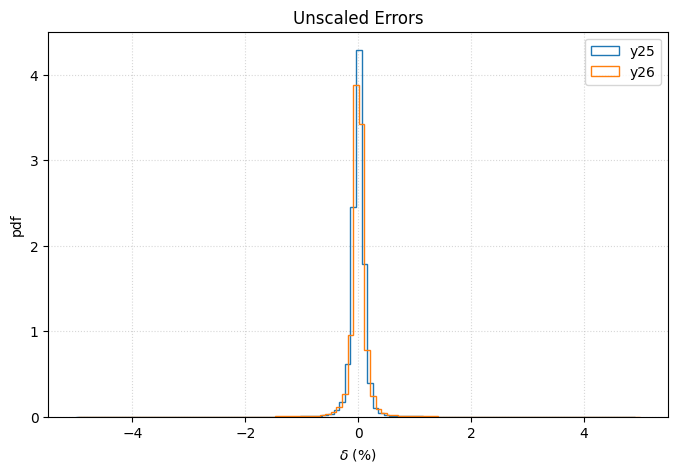

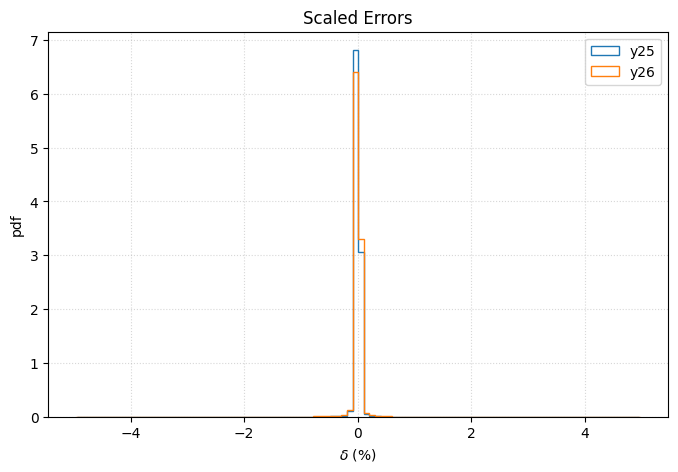

Completed single-model evaluation for y25y26m1

Running single-model evaluation for y25y26m2


/tmp/ipykernel_1860833/3287956048.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y25y26m2

=== Evaluation (SCALED) ===
Overall MAPE: 0.001261
Overall R2  : 0.999953
Overall Abs : 99.873892
y25: MAPE=0.000513, R2=0.999968, abs=99.948705
y26: MAPE=0.002009, R2=0.999939, abs=99.799078

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.002114
Overall R2  : 0.999797
Overall Abs : 99.788604
y25: MAPE=0.001322, R2=0.999659, abs=99.867808
y26: MAPE=0.002906, R2=0.999935, abs=99.709401


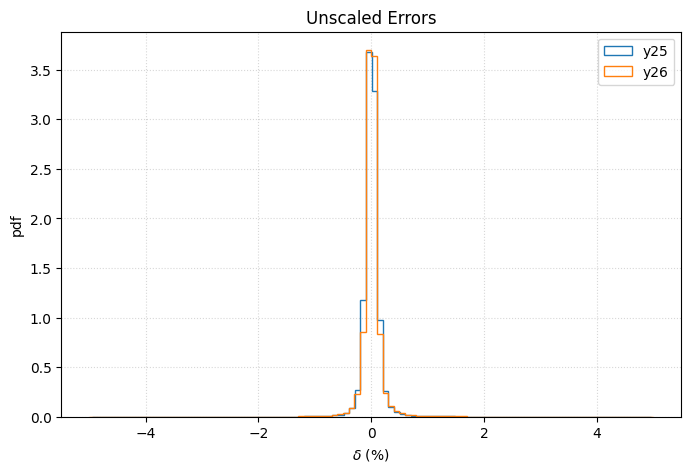

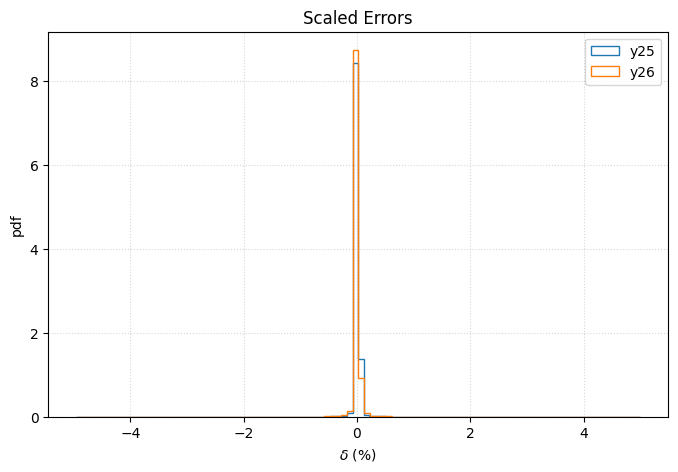

Completed single-model evaluation for y25y26m2

Running single-model evaluation for y25y26m3


/tmp/ipykernel_1860833/3287956048.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y25y26m3

=== Evaluation (SCALED) ===
Overall MAPE: 0.001843
Overall R2  : 0.999947
Overall Abs : 99.815738
y25: MAPE=0.000479, R2=0.999963, abs=99.952078
y26: MAPE=0.003206, R2=0.999931, abs=99.679399

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.002710
Overall R2  : 0.999896
Overall Abs : 99.729034
y25: MAPE=0.001288, R2=0.999826, abs=99.871248
y26: MAPE=0.004132, R2=0.999966, abs=99.586820


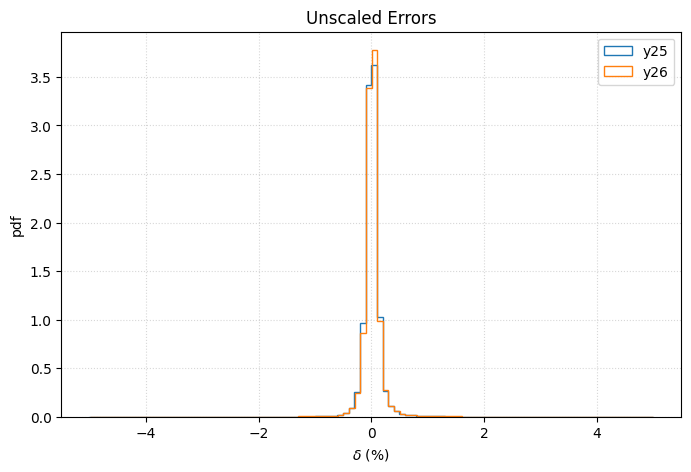

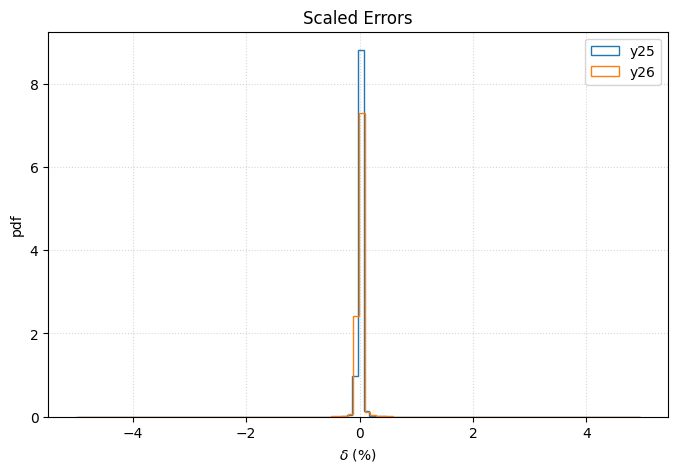

Completed single-model evaluation for y25y26m3

Running single-model evaluation for y25y26m4


/tmp/ipykernel_1860833/3287956048.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y25y26m4

=== Evaluation (SCALED) ===
Overall MAPE: 0.001465
Overall R2  : 0.999944
Overall Abs : 99.853488
y25: MAPE=0.000605, R2=0.999962, abs=99.939548
y26: MAPE=0.002326, R2=0.999927, abs=99.767428

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.002412
Overall R2  : 0.999630
Overall Abs : 99.758816
y25: MAPE=0.001495, R2=0.999371, abs=99.850466
y26: MAPE=0.003328, R2=0.999889, abs=99.667167


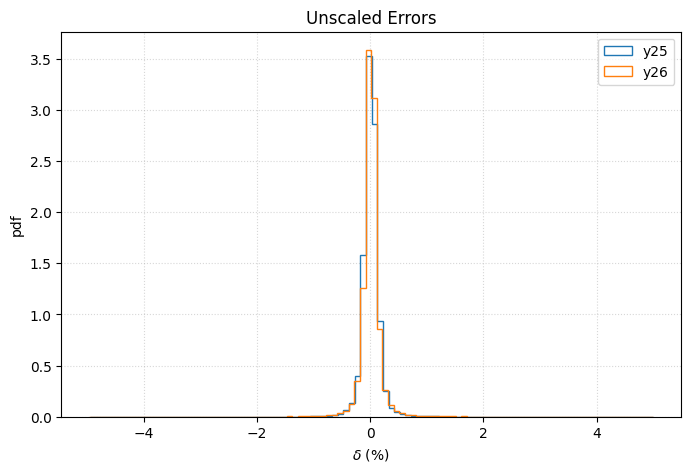

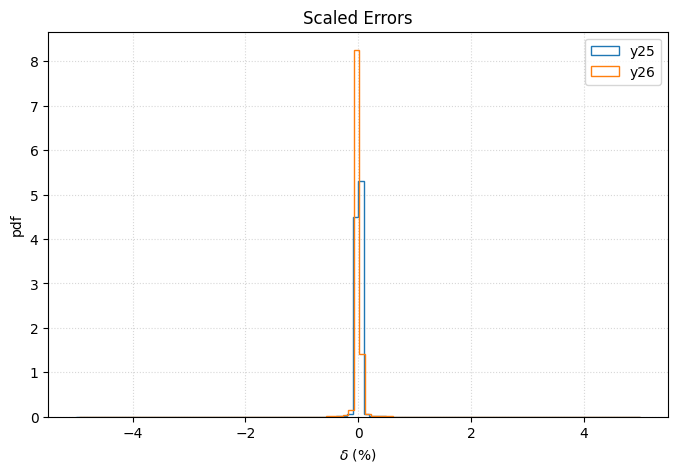

Completed single-model evaluation for y25y26m4

Running single-model evaluation for y25y26m5


/tmp/ipykernel_1860833/3287956048.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y25y26m5

=== Evaluation (SCALED) ===
Overall MAPE: 0.001234
Overall R2  : 0.999949
Overall Abs : 99.876619
y25: MAPE=0.000382, R2=0.999963, abs=99.961817
y26: MAPE=0.002086, R2=0.999935, abs=99.791422

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.002069
Overall R2  : 0.999886
Overall Abs : 99.793103
y25: MAPE=0.001169, R2=0.999829, abs=99.883093
y26: MAPE=0.002969, R2=0.999943, abs=99.703112


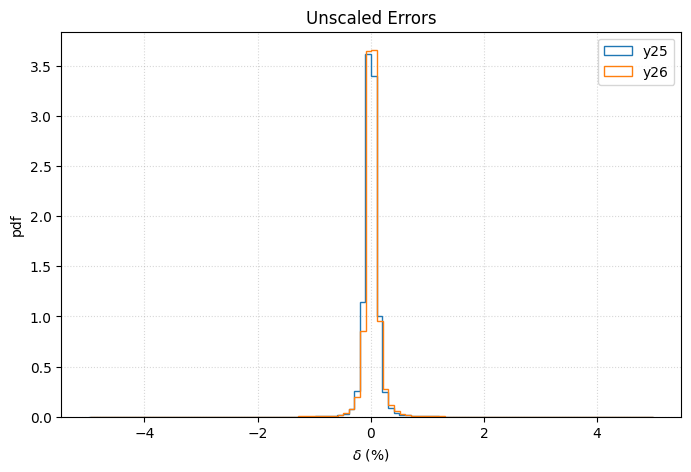

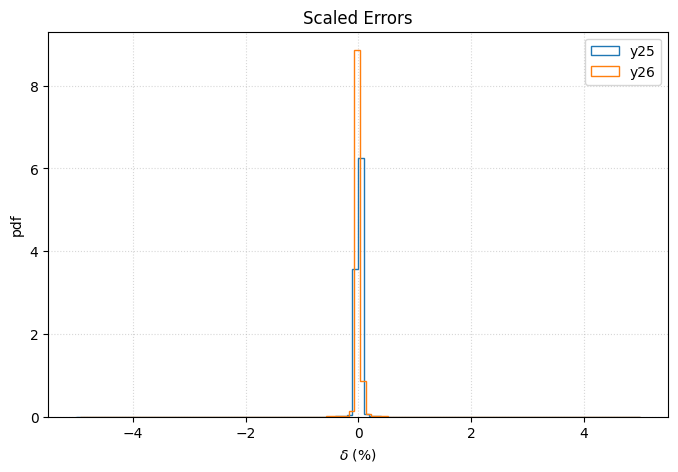

Completed single-model evaluation for y25y26m5

Running ensemble evaluation for pair y25y26

################################################################################
Starting ensemble evaluation for targets: ['y25', 'y26']
Using 5 checkpoints
################################################################################


/tmp/ipykernel_1860833/4202110712.py:131: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.000528
Overall R2  : 0.999954
Overall Abs : 99.947154
y25: MAPE=0.000269, R2=0.999969, abs=99.973096
y26: MAPE=0.000788, R2=0.999940, abs=99.921212

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.000992
Overall R2  : 0.999924
Overall Abs : 99.900820
y25: MAPE=0.000680, R2=0.999865, abs=99.931978
y26: MAPE=0.001303, R2=0.999983, abs=99.869662


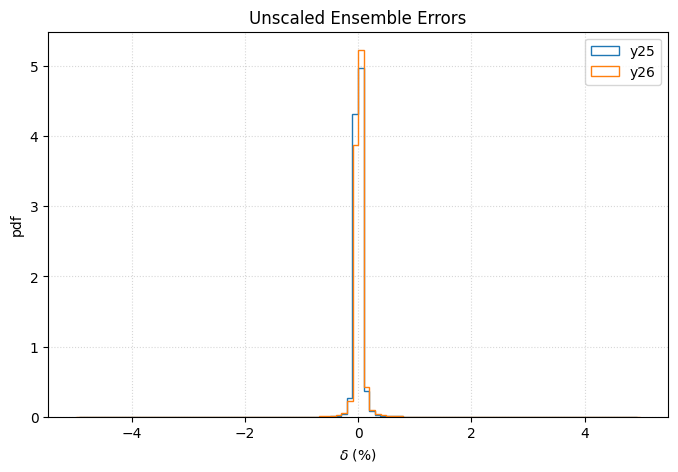

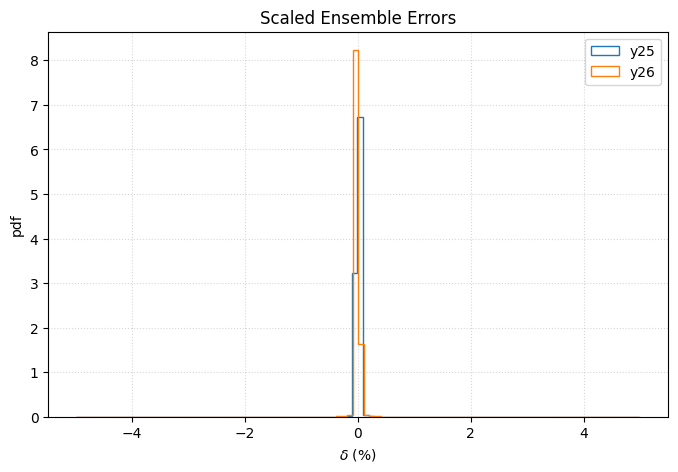

Completed all evaluations for pair y25y26

################################################################################
Preparing evaluation pipeline for pair: y27y28
Seeds to evaluate: [1, 2, 3, 4, 5]
################################################################################


Loading dataset for y27y28 using bootstrap model y27y28m1


[]
['y27', 'y28']


y27y28: 500000 -> 499938 (62 removed, 0.01%)
y27y28: filtered test rows 500000 -> 499938 
Building shared test loader for y27y28

Running single-model evaluation for y27y28m1


/tmp/ipykernel_1860833/3287956048.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y27y28m1

=== Evaluation (SCALED) ===
Overall MAPE: 0.008059
Overall R2  : 0.999999
Overall Abs : 99.194132
y27: MAPE=0.007994, R2=0.999999, abs=99.200594
y28: MAPE=0.008123, R2=0.999999, abs=99.187670

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.008304
Overall R2  : 0.999999
Overall Abs : 99.169567
y27: MAPE=0.008231, R2=0.999999, abs=99.176904
y28: MAPE=0.008378, R2=0.999999, abs=99.162229


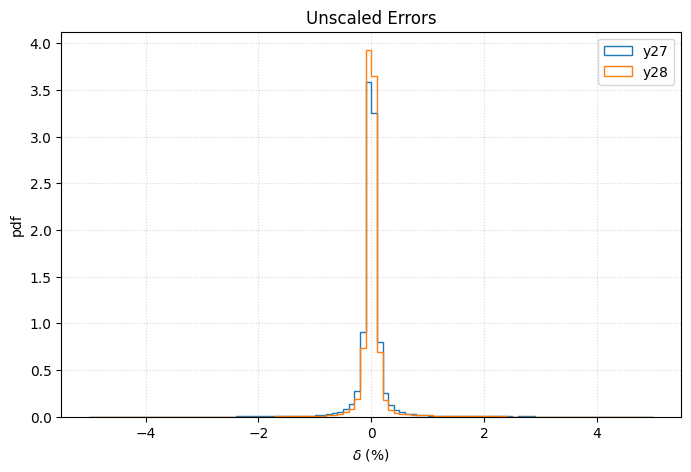

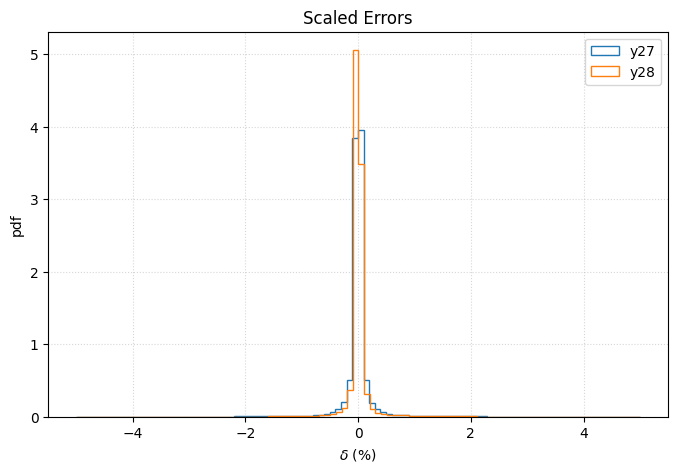

Completed single-model evaluation for y27y28m1

Running single-model evaluation for y27y28m2


/tmp/ipykernel_1860833/3287956048.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y27y28m2

=== Evaluation (SCALED) ===
Overall MAPE: 0.007345
Overall R2  : 0.999999
Overall Abs : 99.265514
y27: MAPE=0.006847, R2=0.999999, abs=99.315278
y28: MAPE=0.007842, R2=0.999999, abs=99.215750

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.007561
Overall R2  : 0.999999
Overall Abs : 99.243890
y27: MAPE=0.007049, R2=0.999999, abs=99.295128
y28: MAPE=0.008073, R2=0.999999, abs=99.192652


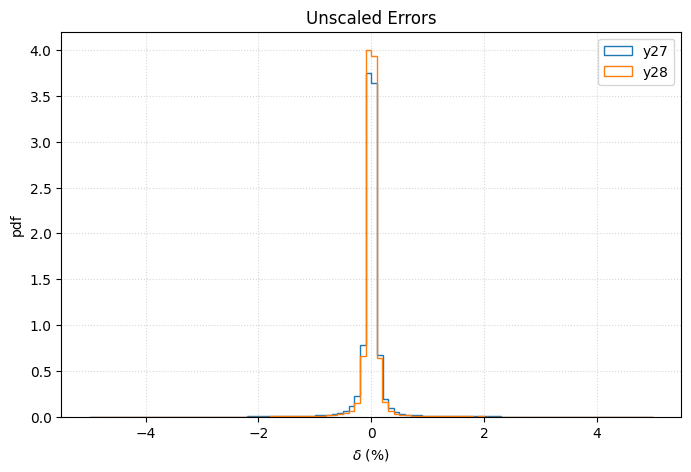

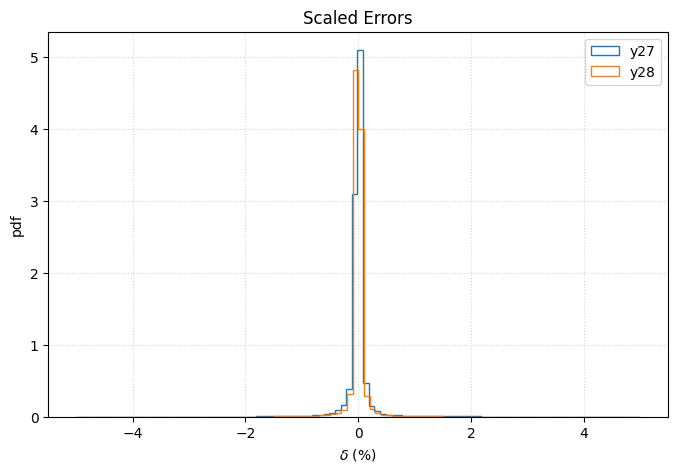

Completed single-model evaluation for y27y28m2

Running single-model evaluation for y27y28m3


/tmp/ipykernel_1860833/3287956048.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y27y28m3

=== Evaluation (SCALED) ===
Overall MAPE: 0.006394
Overall R2  : 0.999999
Overall Abs : 99.360580
y27: MAPE=0.006297, R2=0.999999, abs=99.370343
y28: MAPE=0.006492, R2=0.999999, abs=99.350817

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.006605
Overall R2  : 0.999999
Overall Abs : 99.339519
y27: MAPE=0.006500, R2=0.999999, abs=99.350003
y28: MAPE=0.006710, R2=0.999999, abs=99.329034


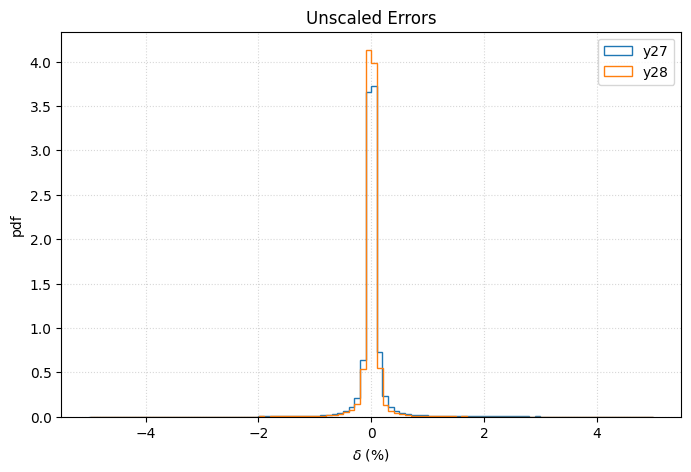

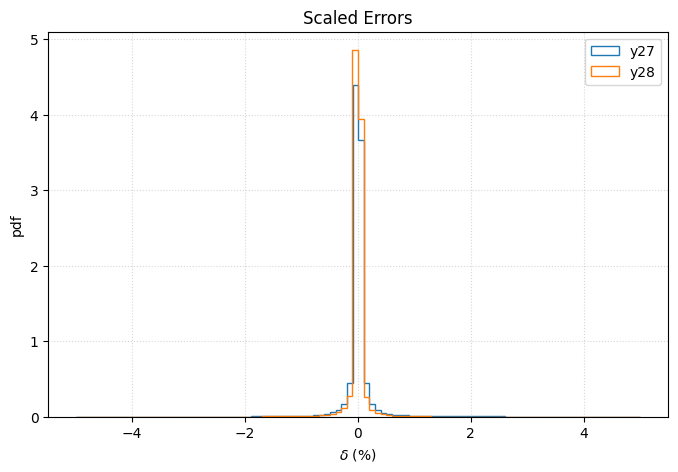

Completed single-model evaluation for y27y28m3

Running single-model evaluation for y27y28m4


/tmp/ipykernel_1860833/3287956048.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y27y28m4

=== Evaluation (SCALED) ===
Overall MAPE: 0.008862
Overall R2  : 0.999999
Overall Abs : 99.113816
y27: MAPE=0.008591, R2=0.999999, abs=99.140895
y28: MAPE=0.009133, R2=0.999999, abs=99.086737

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.009067
Overall R2  : 0.999999
Overall Abs : 99.093340
y27: MAPE=0.008785, R2=0.999999, abs=99.121461
y28: MAPE=0.009348, R2=0.999999, abs=99.065219


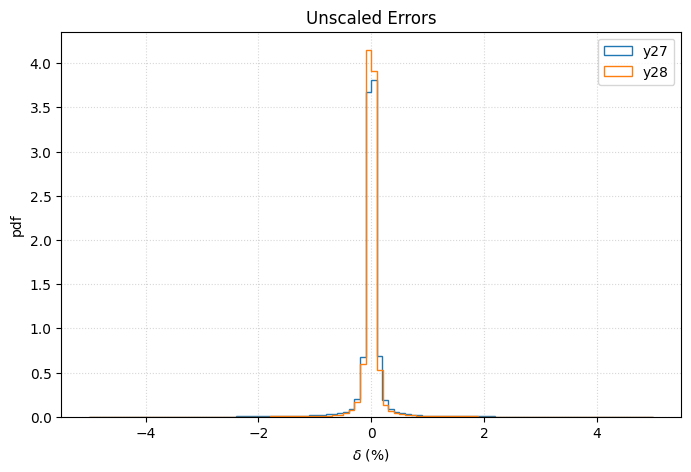

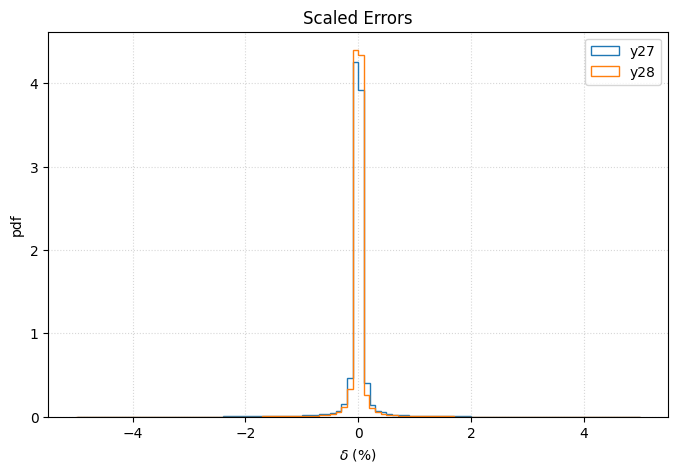

Completed single-model evaluation for y27y28m4

Running single-model evaluation for y27y28m5


/tmp/ipykernel_1860833/3287956048.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y27y28m5

=== Evaluation (SCALED) ===
Overall MAPE: 0.006191
Overall R2  : 0.999999
Overall Abs : 99.380887
y27: MAPE=0.007405, R2=0.999999, abs=99.259499
y28: MAPE=0.004977, R2=0.999999, abs=99.502275

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.006407
Overall R2  : 0.999999
Overall Abs : 99.359342
y27: MAPE=0.007610, R2=0.999999, abs=99.239015
y28: MAPE=0.005203, R2=0.999999, abs=99.479670


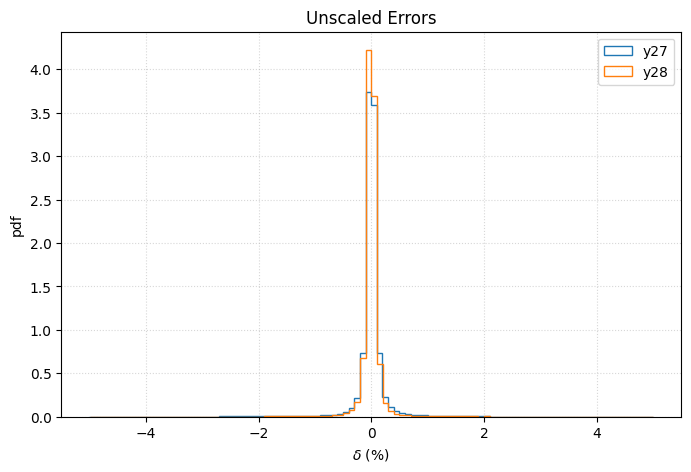

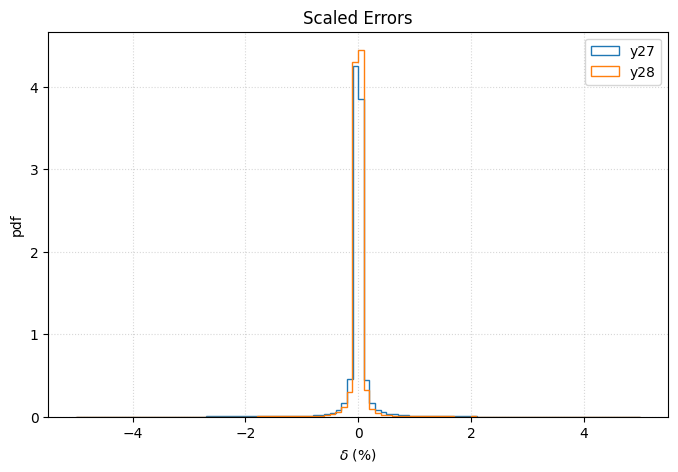

Completed single-model evaluation for y27y28m5

Running ensemble evaluation for pair y27y28

################################################################################
Starting ensemble evaluation for targets: ['y27', 'y28']
Using 5 checkpoints
################################################################################


/tmp/ipykernel_1860833/4202110712.py:131: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.004988
Overall R2  : 1.000000
Overall Abs : 99.501162
y27: MAPE=0.004770, R2=1.000000, abs=99.522971
y28: MAPE=0.005206, R2=1.000000, abs=99.479352

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.005090
Overall R2  : 1.000000
Overall Abs : 99.490990
y27: MAPE=0.004868, R2=1.000000, abs=99.513223
y28: MAPE=0.005312, R2=1.000000, abs=99.468758


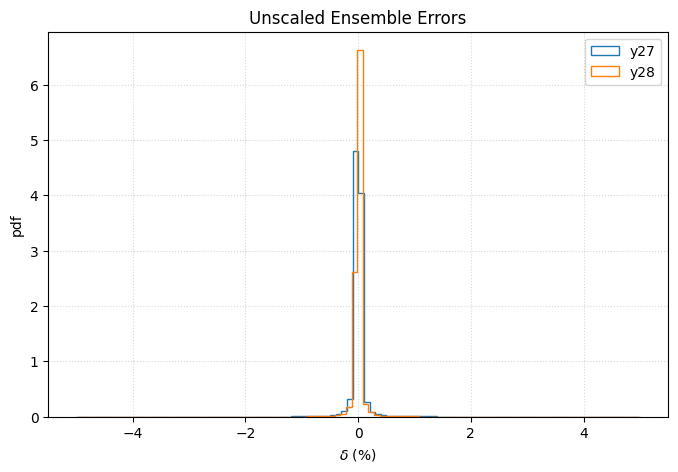

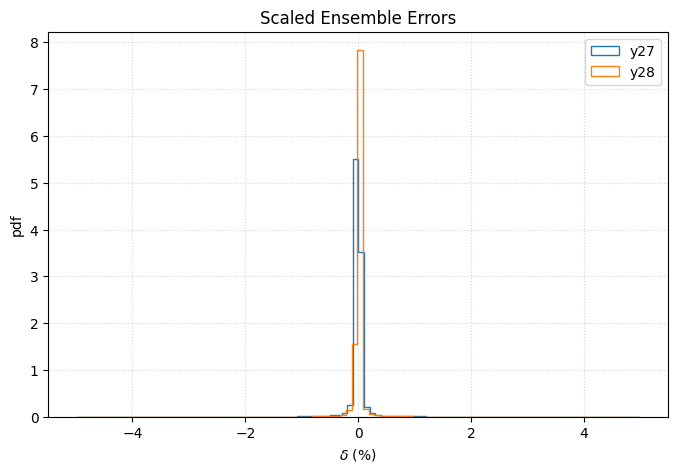

Completed all evaluations for pair y27y28

################################################################################
Preparing evaluation pipeline for pair: y7y78
Seeds to evaluate: [1, 2, 3, 4, 5]
################################################################################


IndexError: single positional indexer is out-of-bounds

In [ ]:
MODEL_PAIRS = ["y25y26", "y27y28", "y7y78", "y11y12", "y3y4"]
MODEL_SEEDS = [1, 2, 3, 4, 5]
ARTIFACT_ROOT = "./artifacts"
DATA_DIR = "/scratch/akula.ha/dataset"
OUTLIER_STD = 4.3

all_results = {}

for pair in MODEL_PAIRS:
    print(f"\n{'#' * 80}")
    print(f"Preparing evaluation pipeline for pair: {pair}")
    print(f"Seeds to evaluate: {MODEL_SEEDS}")
    print(f"{'#' * 80}")

    pair_bootstrap_uuid = f"{pair}m{MODEL_SEEDS[0]}"
    _, pair_config = load_model_artifacts(pair_bootstrap_uuid, ARTIFACT_ROOT)
    pair_config["data_dir"] = DATA_DIR

    print(f"Loading dataset for {pair} using bootstrap model {pair_bootstrap_uuid}")
    df, spark = load_data(pair_config)

    x_cols = ['x1', 'x2', 'x3', 'x4']
    y_cols = pair_config["var_y"]

    test_df = df["test"].copy(deep=True)
    # filtered_test_df = filter_test_dataframe(
    #     test_df,
    #     y_cols,
    #     outlier_std=OUTLIER_STD,
    # )
    # filtered_test_df = filter_test_dataframe_std(
    #     test_df,
    #     cols=y_cols,  # or y_cols
    #     threshold=OUTLIER_STD,
    # )

    # create scaled versions dynamically
    scaled_cols = [f"{col}_scaled" for col in y_cols]

    for col, scol in zip(y_cols, scaled_cols):
        test_df[scol] = test_df[col].apply(y_scale)

    # filter using scaled cols
    # filtered_test_df = filter_test_dataframe_std(
    #     test_df,
    #     cols=scaled_cols,
    #     threshold=OUTLIER_STD,
    # )
    filtered_test_df = filter_test_dataframe_min_abs(
        test_df,
        cols=scaled_cols,  # or y_cols depending on what you want
        threshold=1e-5,
    )
    before = len(test_df)
    after = len(filtered_test_df)

    print(f"{pair}: {before} -> {after} ({before - after} removed, {(before-after)/before*100:.2f}%)")
    print(
        f"{pair}: filtered test rows {len(test_df)} -> {len(filtered_test_df)} "
        # f"using {OUTLIER_STD} std"
    )
    print(f"Building shared test loader for {pair}")

    pair_test_dataset = MyDataset(
        filtered_test_df[x_cols],
        filtered_test_df[y_cols],
        pair_config,
    )
    batch_size = pair_config["batch_size"]
    numworkers = 4 if get_device().type == 'cpu' else 0
    pair_test_loader = torch.utils.data.DataLoader(
        pair_test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=numworkers,
        drop_last=False,
    )

    all_results[pair] = {}
    pair_checkpoint_paths = []

    for seed in MODEL_SEEDS:
        model_uuid = f"{pair}m{seed}"
        print(f"\n{'=' * 80}")
        print(f"Running single-model evaluation for {model_uuid}")
        print(f"{'=' * 80}")

        weights_path, seed_config = load_model_artifacts(model_uuid, ARTIFACT_ROOT)
        seed_config["data_dir"] = DATA_DIR
        pair_checkpoint_paths.append(weights_path)
        print(f"Loaded artifacts for {model_uuid}")

        width = seed_config['width']
        depth = seed_config['depth']
        n_skip_layers = seed_config['skip_block_layers']
        activation = seed_config['activation']

        seed_model = SkipModel(
            seed_config["input_shape"],
            width,
            depth,
            n_skip_layers,
            len(seed_config["var_y"]),
            activation,
        )
        seed_model.to(device=get_device())
        seed_model.load_state_dict(
            torch.load(
                weights_path,
                map_location=torch.device(
                    'cuda' if torch.cuda.is_available() else 'cpu'
                ),
            )
        )

        test_metrics, df_pred = test_model(seed_model, pair_test_loader, seed_config)
        scaled_metrics, unscaled_metrics = evaluate_model(
            seed_model, pair_test_loader, get_device(), seed_config, eps=0
        )
        print(f"Completed single-model evaluation for {model_uuid}")

        all_results[pair][seed] = {
            "model_uuid": model_uuid,
            "config": seed_config,
            "filtered_test_df": filtered_test_df.copy(deep=True),
            "test_metrics": test_metrics,
            "scaled_metrics": scaled_metrics,
            "unscaled_metrics": unscaled_metrics,
            "df_pred": df_pred,
        }

    print(f"\n{'=' * 80}")
    print(f"Running ensemble evaluation for pair {pair}")
    print(f"{'=' * 80}")
    all_results[pair]["ensemble"] = run_ensemble_evaluation(
        test_df=filtered_test_df,
        checkpoint_paths=pair_checkpoint_paths,
        config=pair_config,
        dataloader=pair_test_loader,
        eps=0,
    )
    print(f"Completed all evaluations for pair {pair}")



################################################################################
Preparing evaluation pipeline for pair: y27y28
Seeds to evaluate: [1, 2, 3, 4, 5]
################################################################################


Loading dataset for y27y28 using bootstrap model y27y28m1


[]
['y27', 'y28']


y27y28: 500000 -> 499988 (12 removed, 0.00%)
y27y28: filtered test rows 500000 -> 499988 using 4.3 std
Building shared test loader for y27y28

Running single-model evaluation for y27y28m1


/tmp/ipykernel_1860833/147029401.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y27y28m1

=== Evaluation (SCALED) ===
Overall MAPE: 0.017561
Overall R2  : 0.999999
Overall Abs : 98.243948
y27: MAPE=0.015183, R2=0.999999, abs=98.481703
y28: MAPE=0.019938, R2=0.999999, abs=98.006194

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.017809
Overall R2  : 0.999999
Overall Abs : 98.219146
y27: MAPE=0.015422, R2=0.999999, abs=98.457828
y28: MAPE=0.020195, R2=0.999999, abs=97.980464


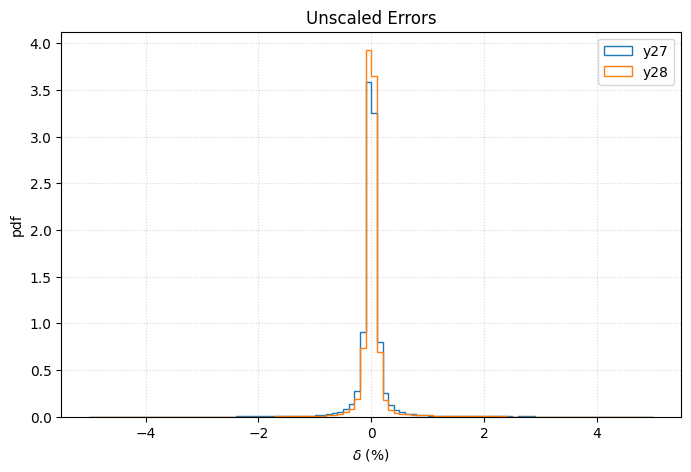

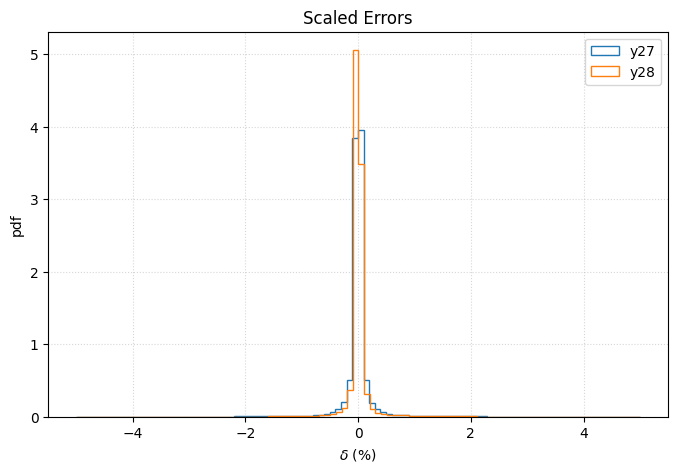

Completed single-model evaluation for y27y28m1

Running single-model evaluation for y27y28m2


Loaded artifacts for y27y28m2


/tmp/ipykernel_1860833/147029401.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(



=== Evaluation (SCALED) ===
Overall MAPE: 0.017151
Overall R2  : 0.999999
Overall Abs : 98.284872
y27: MAPE=0.014495, R2=0.999999, abs=98.550503
y28: MAPE=0.019808, R2=0.999999, abs=98.019241

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.017370
Overall R2  : 0.999999
Overall Abs : 98.262952
y27: MAPE=0.014698, R2=0.999999, abs=98.530158
y28: MAPE=0.020043, R2=0.999999, abs=97.995746


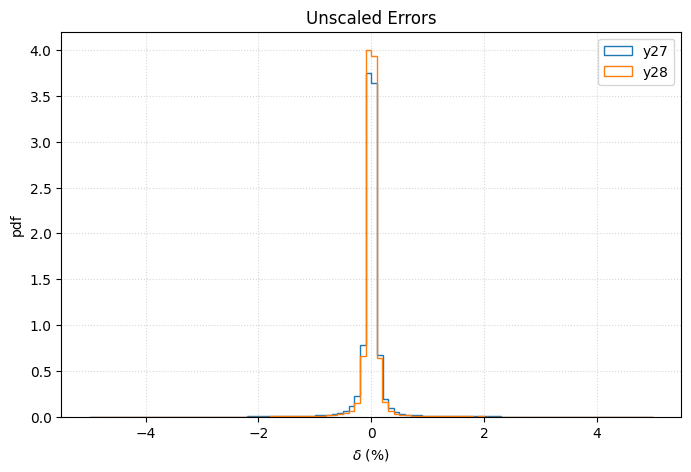

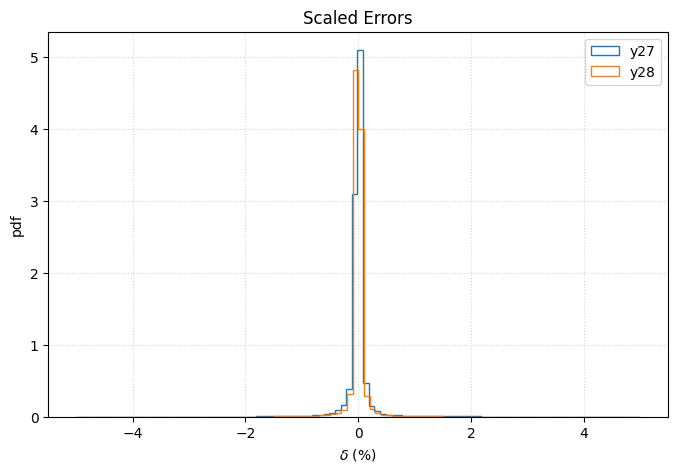

Completed single-model evaluation for y27y28m2

Running single-model evaluation for y27y28m3


/tmp/ipykernel_1860833/147029401.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y27y28m3

=== Evaluation (SCALED) ===
Overall MAPE: 0.014121
Overall R2  : 0.999999
Overall Abs : 98.587917
y27: MAPE=0.012325, R2=0.999999, abs=98.767519
y28: MAPE=0.015917, R2=0.999999, abs=98.408315

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.014334
Overall R2  : 0.999999
Overall Abs : 98.566634
y27: MAPE=0.012530, R2=0.999999, abs=98.747041
y28: MAPE=0.016138, R2=0.999999, abs=98.386226


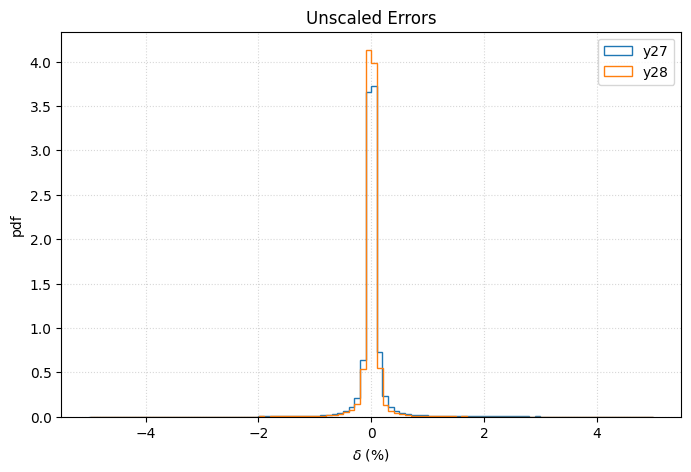

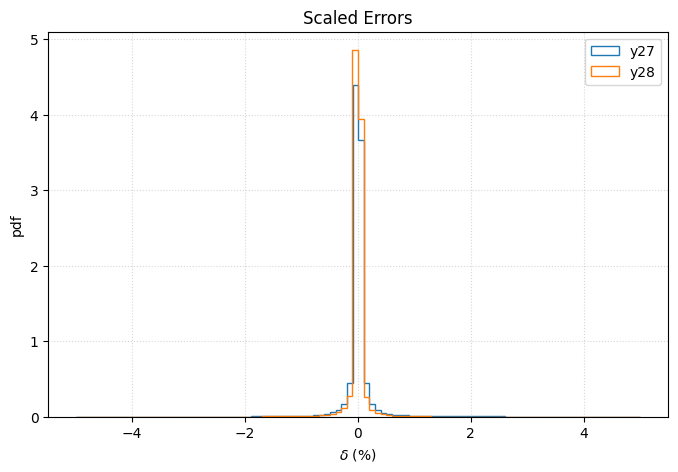

Completed single-model evaluation for y27y28m3

Running single-model evaluation for y27y28m4


/tmp/ipykernel_1860833/147029401.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y27y28m4

=== Evaluation (SCALED) ===
Overall MAPE: 0.022923
Overall R2  : 0.999999
Overall Abs : 97.707707
y27: MAPE=0.019811, R2=0.999999, abs=98.018890
y28: MAPE=0.026035, R2=0.999999, abs=97.396523

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.023133
Overall R2  : 0.999999
Overall Abs : 97.686690
y27: MAPE=0.020009, R2=0.999999, abs=97.999070
y28: MAPE=0.026257, R2=0.999999, abs=97.374310


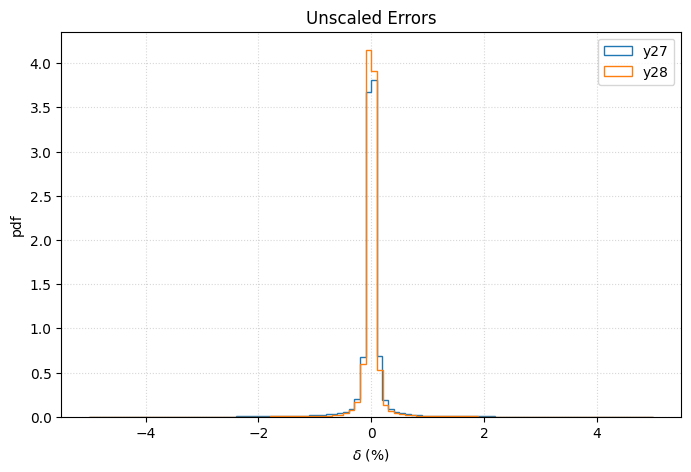

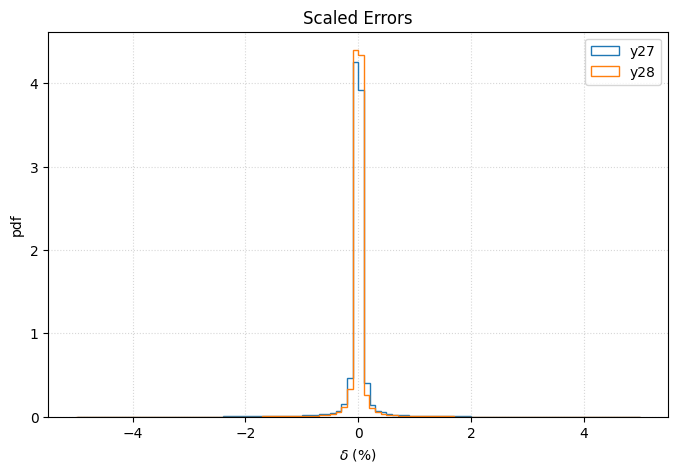

Completed single-model evaluation for y27y28m4

Running single-model evaluation for y27y28m5


/tmp/ipykernel_1860833/147029401.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Loaded artifacts for y27y28m5

=== Evaluation (SCALED) ===
Overall MAPE: 0.015532
Overall R2  : 0.999999
Overall Abs : 98.446841
y27: MAPE=0.018408, R2=0.999999, abs=98.159207
y28: MAPE=0.012655, R2=0.999999, abs=98.734475

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.015750
Overall R2  : 0.999999
Overall Abs : 98.425048
y27: MAPE=0.018616, R2=0.999999, abs=98.138385
y28: MAPE=0.012883, R2=0.999999, abs=98.711711


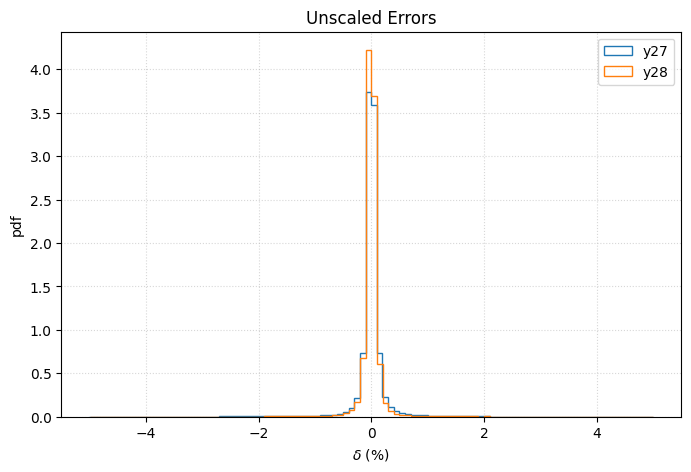

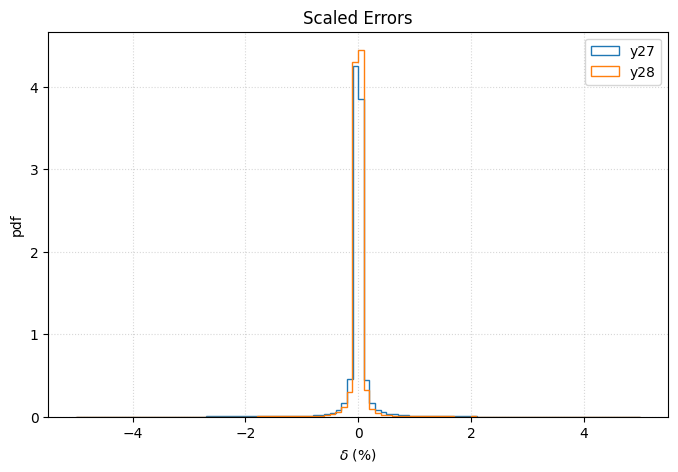

Completed single-model evaluation for y27y28m5

Running ensemble evaluation for pair y27y28

################################################################################
Starting ensemble evaluation for targets: ['y27', 'y28']
Using 5 checkpoints
################################################################################


/tmp/ipykernel_1860833/4202110712.py:131: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.013930
Overall R2  : 1.000000
Overall Abs : 98.607017
y27: MAPE=0.012251, R2=1.000000, abs=98.774906
y28: MAPE=0.015609, R2=1.000000, abs=98.439128

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.014033
Overall R2  : 1.000000
Overall Abs : 98.596663
y27: MAPE=0.012350, R2=1.000000, abs=98.765020
y28: MAPE=0.015717, R2=1.000000, abs=98.428306


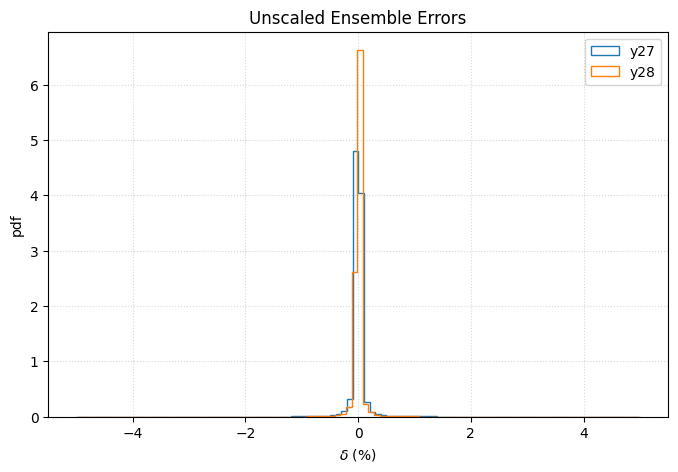

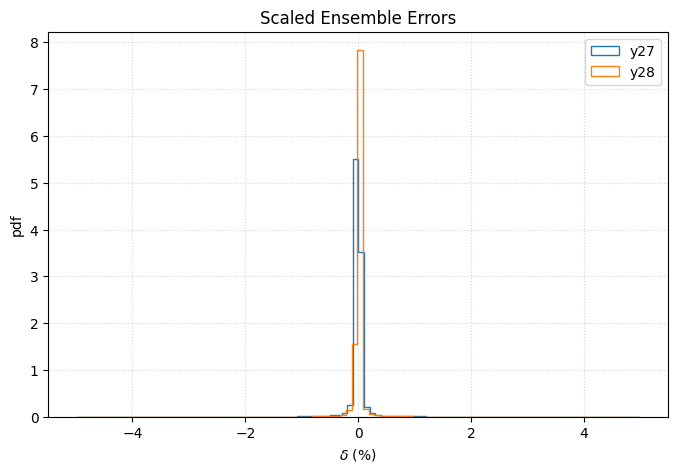

Completed all evaluations for pair y27y28


In [ ]:
MODEL_PAIRS = ["y27y28"] #["y25y26", "y27y28", "y7y78", "y11y12", "y3y4"]
MODEL_SEEDS = [1, 2, 3, 4, 5]
ARTIFACT_ROOT = "./artifacts"
DATA_DIR = "/scratch/akula.ha/dataset"
OUTLIER_STD = 4.3

all_results = {}

for pair in MODEL_PAIRS:
    print(f"\n{'#' * 80}")
    print(f"Preparing evaluation pipeline for pair: {pair}")
    print(f"Seeds to evaluate: {MODEL_SEEDS}")
    print(f"{'#' * 80}")

    pair_bootstrap_uuid = f"{pair}m{MODEL_SEEDS[0]}"
    _, pair_config = load_model_artifacts(pair_bootstrap_uuid, ARTIFACT_ROOT)
    pair_config["data_dir"] = DATA_DIR

    print(f"Loading dataset for {pair} using bootstrap model {pair_bootstrap_uuid}")
    df, spark = load_data(pair_config)

    x_cols = ['x1', 'x2', 'x3', 'x4']
    y_cols = pair_config["var_y"]

    test_df = df["test"].copy(deep=True)
    # filtered_test_df = filter_test_dataframe(
    #     test_df,
    #     y_cols,
    #     outlier_std=OUTLIER_STD,
    # )
    # filtered_test_df = filter_test_dataframe_std(
    #     test_df,
    #     cols=y_cols,  # or y_cols
    #     threshold=OUTLIER_STD,
    # )

    # create scaled versions dynamically
    scaled_cols = [f"{col}_scaled" for col in y_cols]

    for col, scol in zip(y_cols, scaled_cols):
        test_df[scol] = test_df[col].apply(y_scale)

    # filter using scaled cols
    # filtered_test_df = filter_test_dataframe_std(
    #     test_df,
    #     cols=scaled_cols,
    #     threshold=OUTLIER_STD,
    # )
    filtered_test_df = filter_test_dataframe_min_abs(
        test_df,
        cols=scaled_cols,  # or y_cols depending on what you want
        threshold=1e-6,
    )
    before = len(test_df)
    after = len(filtered_test_df)

    print(f"{pair}: {before} -> {after} ({before - after} removed, {(before-after)/before*100:.2f}%)")
    print(
        f"{pair}: filtered test rows {len(test_df)} -> {len(filtered_test_df)} "
        f"using {OUTLIER_STD} std"
    )
    print(f"Building shared test loader for {pair}")

    pair_test_dataset = MyDataset(
        filtered_test_df[x_cols],
        filtered_test_df[y_cols],
        pair_config,
    )
    batch_size = pair_config["batch_size"]
    numworkers = 4 if get_device().type == 'cpu' else 0
    pair_test_loader = torch.utils.data.DataLoader(
        pair_test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=numworkers,
        drop_last=False,
    )

    all_results[pair] = {}
    pair_checkpoint_paths = []

    for seed in MODEL_SEEDS:
        model_uuid = f"{pair}m{seed}"
        print(f"\n{'=' * 80}")
        print(f"Running single-model evaluation for {model_uuid}")
        print(f"{'=' * 80}")

        weights_path, seed_config = load_model_artifacts(model_uuid, ARTIFACT_ROOT)
        seed_config["data_dir"] = DATA_DIR
        pair_checkpoint_paths.append(weights_path)
        print(f"Loaded artifacts for {model_uuid}")

        width = seed_config['width']
        depth = seed_config['depth']
        n_skip_layers = seed_config['skip_block_layers']
        activation = seed_config['activation']

        seed_model = SkipModel(
            seed_config["input_shape"],
            width,
            depth,
            n_skip_layers,
            len(seed_config["var_y"]),
            activation,
        )
        seed_model.to(device=get_device())
        seed_model.load_state_dict(
            torch.load(
                weights_path,
                map_location=torch.device(
                    'cuda' if torch.cuda.is_available() else 'cpu'
                ),
            )
        )

        test_metrics, df_pred = test_model(seed_model, pair_test_loader, seed_config)
        scaled_metrics, unscaled_metrics = evaluate_model(
            seed_model, pair_test_loader, get_device(), seed_config, eps=0
        )
        print(f"Completed single-model evaluation for {model_uuid}")

        all_results[pair][seed] = {
            "model_uuid": model_uuid,
            "config": seed_config,
            "filtered_test_df": filtered_test_df.copy(deep=True),
            "test_metrics": test_metrics,
            "scaled_metrics": scaled_metrics,
            "unscaled_metrics": unscaled_metrics,
            "df_pred": df_pred,
        }

    print(f"\n{'=' * 80}")
    print(f"Running ensemble evaluation for pair {pair}")
    print(f"{'=' * 80}")
    all_results[pair]["ensemble"] = run_ensemble_evaluation(
        test_df=filtered_test_df,
        checkpoint_paths=pair_checkpoint_paths,
        config=pair_config,
        dataloader=pair_test_loader,
        eps=0,
    )
    print(f"Completed all evaluations for pair {pair}")


In [ ]:
# MODEL_PAIRS = ["y25y26"]
# MODEL_SEEDS = [1, 2, 3, 4, 5]
# ARTIFACT_ROOT = "./artifacts"
# DATA_DIR = "/scratch/akula.ha/dataset"
# OUTLIER_STD = 10.0

# all_results = {}

# for pair in MODEL_PAIRS:
#     print(f"\n{'#' * 80}")
#     print(f"Preparing evaluation pipeline for pair: {pair}")
#     print(f"Seeds to evaluate: {MODEL_SEEDS}")
#     print(f"{'#' * 80}")

#     pair_bootstrap_uuid = f"{pair}m{MODEL_SEEDS[0]}"
#     _, pair_config = load_model_artifacts(pair_bootstrap_uuid, ARTIFACT_ROOT)
#     pair_config["data_dir"] = DATA_DIR

#     print(f"Loading dataset for {pair} using bootstrap model {pair_bootstrap_uuid}")
#     df, spark = load_data(pair_config)

#     x_cols = ['x1', 'x2', 'x3', 'x4']
#     y_cols = pair_config["var_y"]

#     test_df = df["test"].copy(deep=True)
#     mask = pd.Series(True, index=test_df.index)
#     for col in y_cols:
#         mean = test_df[col].mean()
#         std = test_df[col].std()
#         if pd.notna(std) and std != 0:
#             mask &= (test_df[col] - mean).abs() <= (OUTLIER_STD * std)

#     filtered_test_df = test_df.loc[mask].reset_index(drop=True)
#     print(
#         f"{pair}: filtered test rows {len(test_df)} -> {len(filtered_test_df)} "
#         f"using {OUTLIER_STD} std"
#     )
#     print(f"Building shared test loader for {pair}")

#     pair_test_dataset = MyDataset(
#         filtered_test_df[x_cols],
#         filtered_test_df[y_cols],
#         pair_config,
#     )
#     batch_size = pair_config["batch_size"]
#     numworkers = 4 if get_device().type == 'cpu' else 0
#     pair_test_loader = torch.utils.data.DataLoader(
#         pair_test_dataset,
#         batch_size=batch_size,
#         shuffle=False,
#         num_workers=numworkers,
#         drop_last=False,
#     )

#     all_results[pair] = {}
#     pair_checkpoint_paths = []

#     for seed in MODEL_SEEDS:
#         model_uuid = f"{pair}m{seed}"
#         print(f"\n{'=' * 80}")
#         print(f"Running single-model evaluation for {model_uuid}")
#         print(f"{'=' * 80}")

#         weights_path, seed_config = load_model_artifacts(model_uuid, ARTIFACT_ROOT)
#         seed_config["data_dir"] = DATA_DIR
#         pair_checkpoint_paths.append(weights_path)
#         print(f"Loaded artifacts for {model_uuid}")

#         width = seed_config['width']
#         depth = seed_config['depth']
#         n_skip_layers = seed_config['skip_block_layers']
#         activation = seed_config['activation']

#         seed_model = SkipModel(
#             seed_config["input_shape"],
#             width,
#             depth,
#             n_skip_layers,
#             len(seed_config["var_y"]),
#             activation,
#         )
#         seed_model.to(device=get_device())
#         seed_model.load_state_dict(
#             torch.load(
#                 weights_path,
#                 map_location=torch.device(
#                     'cuda' if torch.cuda.is_available() else 'cpu'
#                 ),
#             )
#         )

#         test_metrics, df_pred = test_model(seed_model, pair_test_loader, seed_config)
#         scaled_metrics, unscaled_metrics = evaluate_model(
#             seed_model, pair_test_loader, get_device(), seed_config, eps=0
#         )
#         print(f"Completed single-model evaluation for {model_uuid}")

#         all_results[pair][seed] = {
#             "model_uuid": model_uuid,
#             "config": seed_config,
#             "filtered_test_df": filtered_test_df.copy(deep=True),
#             "test_metrics": test_metrics,
#             "scaled_metrics": scaled_metrics,
#             "unscaled_metrics": unscaled_metrics,
#             "df_pred": df_pred,
#         }

#     print(f"\n{'=' * 80}")
#     print(f"Running ensemble evaluation for pair {pair}")
#     print(f"{'=' * 80}")
#     all_results[pair]["ensemble"] = run_ensemble_evaluation(
#         test_df=filtered_test_df,
#         checkpoint_paths=pair_checkpoint_paths,
#         config=pair_config,
#         dataloader=pair_test_loader,
#         eps=0,
#     )
#     print(f"Completed all evaluations for pair {pair}")
